### Install varseek, and import all packages

In [1]:
try:
    import varseek as vk
except ImportError:
    print("varseek not found, installing...")
    !pip install -U -q varseek

In [2]:
import os
import re
import anndata as ad
import pandas as pd
import pysam

import varseek as vk

In [3]:
# !pip install -q ipython-autotime
%load_ext autotime

time: 69.9 μs (started: 2026-08-07 18:20:32 -07:00)


# [vk denovo](https://github.com/pachterlab/varseek) on HG003 (GIAB Ashkenazi father) — benchmarked against ground truth

This notebook runs the **varseek de novo** pipeline (`vk denovo` → `vk ref` → `vk count`) on
**HG003 / NA24149** — the father of the Genome in a Bottle Ashkenazi trio — then compares the
calls **directly to the GIAB HG003 v4.2.1 truth set** with `hap.py`, the standard germline
small-variant benchmarking tool.

**Why HG003 rather than NA12878/HG001?** DeepVariant's released models are trained on the GIAB
samples HG001, HG002, HG004, HG005, HG006 and HG007, with **HG003 deliberately held out** as the
test sample (within the training samples, chr1–19 are used for training and chr21–22 for
validation, so chr20 is held out as well). Benchmarking on NA12878 therefore pits varseek — which
has no learned parameters at all — against a caller that saw that genome during training. HG003
removes that advantage entirely: it is the sample DeepVariant's own case studies report on, and it
has a GIAB v4.2.1 truth set of the same quality as HG001's. See
[DeepVariant training data](https://github.com/google/deepvariant/blob/r1.6.1/docs/deepvariant-details-training-data.md).

**Scope: chromosome 20** (the canonical GIAB benchmarking chromosome), inside the GIAB
high-confidence regions. This keeps the demo tractable while giving a real ground-truth comparison.

**Data**
- Reads: `HG003.novaseq.pcr-free.35x.dedup.grch38_no_alt.chr20.bam` (~35× PCR-free NovaSeq,
  2×151 bp), chr20 only — the same read set DeepVariant's published WGS case study evaluates on.
  Re-aligned to the Ensembl GRCh38 chr20 index below.
- Reference: Ensembl GRCh38 primary assembly (already used by `vk_denovo.ipynb`).
- Truth: `HG003_GRCh38_1_22_v4.2.1_benchmark.vcf.gz` + the high-confidence
  `HG003_GRCh38_1_22_v4.2.1_benchmark_noinconsistent.bed`, restricted to chr20 and renamed to
  Ensembl contig naming (`chr20` → `20`).

> Because the input is whole-genome **DNA** (not RNA), `vk denovo` aligns with **bowtie2**
> (DNA aligner) rather than STAR, and `vk count` runs in `bulk`/`paired` mode.


### Define paths and parameters

In [4]:
import os, re, gzip, subprocess
import numpy as np
import pandas as pd
import anndata as ad
import pysam

# ---- reference (shared with vk_denovo.ipynb) ----
reference_dir = os.path.join("data", "reference")
sequences = os.path.join(reference_dir, "ensembl_grch38_release114", "Homo_sapiens.GRCh38.dna.primary_assembly.fa")
gtf = os.path.join(reference_dir, "ensembl_grch38_release114", "Homo_sapiens.GRCh38.114.gtf")

# ---- HG003 (GIAB Ashkenazi father, NA24149) chr20 working dir ----
sample = "HG003"
root = os.path.join("data", "hg003_chr20")
reads_dir = os.path.join(root, "reads")
r1 = os.path.join(reads_dir, f"{sample}_chr20_R1.fastq.gz")
r2 = os.path.join(reads_dir, f"{sample}_chr20_R2.fastq.gz")
chr20_bam = os.path.join(reads_dir, "chr20.bam")

bowtie2_index_prefix = os.path.join(reference_dir, "bowtie2_chr20", "chr20")

# vk denovo out
variants_dir = os.path.join(root, "varseek_denovo_out")
variants_vcf = os.path.join(variants_dir, "variants.vcf.gz")
variants = os.path.join(variants_dir, "variants.tsv")
denovo_bam_dir = os.path.join(variants_dir, "bams")

# vk ref out
vk_ref_out_dir = os.path.join(root, "varseek_ref_out")
vcrs_index = os.path.join(vk_ref_out_dir, "vcrs_index_denovo.idx")
vcrs_t2g = os.path.join(vk_ref_out_dir, "vcrs_t2g_denovo.txt")

# vk count out
vk_count_out_dir = os.path.join(root, "varseek_count_out")
vk_count_variants_vcf = os.path.join(vk_count_out_dir, "varseek_variants.vcf")

# GIAB truth
giab_dir = os.path.join(root, "giab")
truth_vcf = os.path.join(giab_dir, "truth_chr20_ens.vcf.gz")
confident_bed = os.path.join(giab_dir, "confident_chr20_ens.bed")

# hap.py out
happy_out = os.path.join(root, "happy_output")

# general parameters
k = 41
w = k - 1
min_counts_denovo = 3          # vk denovo: min reads supporting a candidate (INFO/AO)
min_counts_clean = 1           # vk clean: per-entry floor (no-op here; see the recount cell)
min_supporting_reads = 3       # vk count: min reads compatible with a VCRS to call it detected
threads = 16
read_length = 151          # HG003 NovaSeq PCR-free reads are 2x151

denovo_min_mapq = 20
denovo_min_baseq = 20
denovo_min_vaf = 0.20

time: 1.68 ms (started: 2026-08-07 18:20:32 -07:00)


In [5]:
# --- Tool runtime recording -------------------------------------------------
# Every tool below (vk denovo / vk ref / vk count / DeepVariant / GATK
# HaplotypeCaller / GATK Mutect2) is timed, and its wall-clock runtime in
# seconds is written to `tool_runtimes.json` *immediately* after it finishes.
# Persisting to disk means a recorded time is not forgotten across kernel
# restarts, and is not lost when a later cell re-runs and skips the tool via an
# `if not os.path.exists(...)` guard (in that case the previously recorded time
# is simply kept). The three varseek stages are stored separately here for
# reference; the runtime plot at the end sums them into one "varseek" bar.
import json, time
from contextlib import contextmanager

runtime_json = os.path.join(root, "tool_runtimes.json")

def load_runtimes():
    if os.path.exists(runtime_json):
        with open(runtime_json) as fh:
            return json.load(fh)
    return {}

def save_runtime(name, seconds):
    data = load_runtimes()
    data[name] = seconds
    os.makedirs(os.path.dirname(runtime_json), exist_ok=True)
    with open(runtime_json, "w") as fh:
        json.dump(data, fh, indent=2, sort_keys=True)
    print(f"[runtime] {name}: {seconds:.1f} s ({seconds/60:.2f} min)  ->  {runtime_json}")

@contextmanager
def record_runtime(name):
    _t0 = time.perf_counter()
    try:
        yield
    finally:
        save_runtime(name, time.perf_counter() - _t0)

print(f"Runtimes will be written to: {runtime_json}")
print("Existing recorded runtimes:", load_runtimes())

Runtimes will be written to: data/hg003_chr20/tool_runtimes.json
Existing recorded runtimes: {'deepvariant': 982.9510154761374, 'haplotypecaller': 1842.2564617209136, 'mutect2': 1608.252683032304, 'vk count': 91.78296538814902, 'vk count (COSMIC)': 304.8689940571785, 'vk denovo': 822.8233965337276, 'vk ref': 54.168093986809254, 'vk ref (COSMIC)': 427.26717828959227}
time: 1.38 ms (started: 2026-08-07 18:20:32 -07:00)


In [6]:
if not os.path.exists(sequences):
    sequences_dir = os.path.dirname(sequences)
    !gget ref -w dna -r 114 --out_dir {sequences_dir} -d human
    !gunzip {sequences}.gz

if not os.path.exists(gtf):
    gtf_dir = os.path.dirname(gtf)
    !gget ref -w gtf -r 114 --out_dir {gtf_dir} -d human
    !gunzip {gtf}.gz

time: 521 μs (started: 2026-08-07 18:20:32 -07:00)


### Download HG003 chr20 reads and re-align target

We download the **chr20-only** 35× PCR-free NovaSeq HG003 BAM (~1.1 GB) and convert it to paired
FASTQ. Reads are reference-agnostic, so although that BAM is aligned to GRCh38 with UCSC contig
naming (`chr20`), re-aligning to the Ensembl GRCh38 chr20 index (`20`) below is fine.


In [7]:
# The chr20 slice of the 35x PCR-free NovaSeq HG003 alignment -- the exact read set
# DeepVariant's published WGS case study evaluates on. It is already restricted to chr20,
# so no region extraction is needed (unlike the whole-genome NA12878 BAM this notebook was
# derived from, which had to be streamed by region).
HG003_CHR20_BAM = ("https://storage.googleapis.com/deepvariant/case-study-testdata/"
                   "HG003.novaseq.pcr-free.35x.dedup.grch38_no_alt.chr20.bam")

os.makedirs(reads_dir, exist_ok=True)
if not (os.path.exists(r1) and os.path.exists(r2)):
    if not os.path.exists(chr20_bam):
        # ~1.1 GB; `-C -` resumes an interrupted download instead of restarting it
        subprocess.run(["curl", "-fL", "-C", "-", "-o", chr20_bam, HG003_CHR20_BAM], check=True)
    # collate into read pairs, then emit paired FASTQ (singletons dropped; samtools fastq
    # excludes secondary/supplementary records by default)
    collate = subprocess.Popen(["samtools", "collate", "-@", str(threads), "-u", "-O",
                                chr20_bam, os.path.join(reads_dir, "collate_tmp")],
                               stdout=subprocess.PIPE)
    subprocess.run(["samtools", "fastq", "-@", str(threads), "-1", r1, "-2", r2,
                    "-0", "/dev/null", "-s", os.path.join(reads_dir, "singletons.fastq.gz"),
                    "-n", "-"], stdin=collate.stdout, check=True)
    collate.wait()

n_pairs = sum(1 for _ in gzip.open(r1, "rt")) // 4
print(f"{sample} chr20 read pairs: {n_pairs:,}")


HG003 chr20 read pairs: 9,480,040
time: 19.7 s (started: 2026-08-07 18:20:32 -07:00)


### Build a chr20 bowtie2 index

`vk denovo` aligns DNA reads with bowtie2. The reads were extracted from chr20, so a chr20 index
suffices and is fast to build.

In [8]:
bt2_dir = os.path.dirname(bowtie2_index_prefix)
os.makedirs(bt2_dir, exist_ok=True)
if not os.path.exists(bowtie2_index_prefix + ".1.bt2"):
    chr20_fa = bowtie2_index_prefix + ".fa"
    subprocess.run(f"samtools faidx {sequences} 20 > {chr20_fa}", shell=True, check=True)
    subprocess.run(["bowtie2-build", "--threads", str(threads), chr20_fa, bowtie2_index_prefix],
                   check=True)
print("bowtie2 chr20 index ready:", bowtie2_index_prefix)


bowtie2 chr20 index ready: data/reference/bowtie2_chr20/chr20
time: 933 μs (started: 2026-08-07 18:20:52 -07:00)


### Prepare the GIAB ground-truth VCF and high-confidence BED (chr20, Ensembl naming)

The GIAB truth uses UCSC contig names (`chr20`); our reference uses Ensembl naming (`20`). We
subset to chr20, rename, and left-normalize the truth against the reference. The high-confidence
BED defines where the benchmark is valid — both `vk denovo` calling and `hap.py` evaluation are
restricted to it. Note that HG003's v4.2.1 high-confidence BED carries a `_noinconsistent` suffix
(regions inconsistent with the trio's other members are excluded), unlike HG001's.


In [9]:
os.makedirs(giab_dir, exist_ok=True)
GIAB_REL = ("https://ftp-trace.ncbi.nlm.nih.gov/ReferenceSamples/giab/release/"
            "AshkenazimTrio/HG003_NA24149_father/NISTv4.2.1/GRCh38")
raw_vcf = os.path.join(giab_dir, "HG003_GRCh38_v4.2.1_benchmark.vcf.gz")
raw_bed = os.path.join(giab_dir, "HG003_GRCh38_v4.2.1_benchmark_noinconsistent.bed")

if not os.path.exists(truth_vcf):
    if not os.path.exists(raw_vcf):
        subprocess.run(["curl", "-sL", "-o", raw_vcf,
                        f"{GIAB_REL}/HG003_GRCh38_1_22_v4.2.1_benchmark.vcf.gz"], check=True)
        subprocess.run(["curl", "-sL", "-o", raw_vcf + ".tbi",
                        f"{GIAB_REL}/HG003_GRCh38_1_22_v4.2.1_benchmark.vcf.gz.tbi"], check=True)
    rename = os.path.join(giab_dir, "rename_chr20.txt")
    with open(rename, "w") as fh:
        fh.write("chr20\t20\n")
    p1 = subprocess.Popen(["bcftools", "view", "-r", "chr20", raw_vcf, "-Ou"], stdout=subprocess.PIPE)
    p2 = subprocess.Popen(["bcftools", "annotate", "--rename-chrs", rename, "-Ou"],
                          stdin=p1.stdout, stdout=subprocess.PIPE); p1.stdout.close()
    subprocess.run(["bcftools", "norm", "-f", sequences, "-m", "-both", "-Oz", "-o", truth_vcf],
                   stdin=p2.stdout, check=True); p2.stdout.close(); p1.wait(); p2.wait()
    subprocess.run(["bcftools", "index", "-t", "-f", truth_vcf], check=True)

if not os.path.exists(confident_bed):
    if not os.path.exists(raw_bed):
        subprocess.run(["curl", "-sL", "-o", raw_bed,
                        f"{GIAB_REL}/HG003_GRCh38_1_22_v4.2.1_benchmark_noinconsistent.bed"], check=True)
    subprocess.run("awk -F'\t' '$1==\"chr20\"{sub(/^chr/,\"\",$1);print}' OFS='\t' "
                   f"{raw_bed} > {confident_bed}", shell=True, check=True)

print("truth variants (chr20):", subprocess.run(["bcftools", "view", "-H", truth_vcf],
      capture_output=True, text=True).stdout.count("\n"))
print("confident intervals (chr20):", sum(1 for _ in open(confident_bed)))


truth variants (chr20): 85204
confident intervals (chr20): 11601
time: 478 ms (started: 2026-08-07 18:20:52 -07:00)


### Run `vk denovo`

Align the reads with **bowtie2** and read the de novo candidate variants straight off the
alignment records with the **`bam2vcf`** caller. Calling is *not* restricted to the GIAB
high-confidence BED — that restriction belongs at evaluation time, and `hap.py` applies it via
`-f {confident_bed}` below.

In [10]:
# `variant_caller="bam2vcf"` reads every variant recorded in the alignment records themselves
# (CIGAR indels plus mismatches against the reference) and writes a sites-only VCF with AO/DP/VAF.
# It is a candidate *generator*, not a genotyper: no statistical model, ~15 s instead of ~265 s for
# the bcftools mpileup/call/norm chain. That trade only works if its quality filters are set --
# min_mapq/min_baseq keep mismapped repeat reads and miscalled bases out of the candidate set.
#
# `regions` is deliberately not set: it exists to speed calling up, not to define truth. Restricting
# it to the GIAB BED would make vk denovo structurally blind to 13% of chr20 while the callers it is
# compared against range freely; hap.py already does the confident-region restriction at *evaluation*
# time via `-f {confident_bed}`.
if not os.path.exists(variants):
    with record_runtime("vk denovo"):
        vk.denovo(
            inputs=[r1, r2],
            sequences=sequences,
            parity="paired",
            aligner="bowtie2",
            bowtie2_genome_index_prefix=bowtie2_index_prefix,
            out_bam_dir=denovo_bam_dir,
            # regions=confident_bed,
            output=variants_vcf,
            output_tsv=variants,
            min_counts=min_counts_denovo,
            min_mapq=denovo_min_mapq,
            min_baseq=denovo_min_baseq,
            min_vaf=denovo_min_vaf,
            variant_caller="bam2vcf",
            read_length=read_length,
            threads=threads,
            verbose=1,
            technology="dna"
        )

variants_df = pd.read_csv(variants, sep="\t")
print(f"Number of de novo variants: {len(variants_df):,}")
variants_df.head()

Number of de novo variants: 111,301


,seq_id,variant
0,20,g.61083C>T
1,20,g.61446T>C
2,20,g.61540A>G
3,20,g.61558T>A
4,20,g.61561G>T


time: 59.1 ms (started: 2026-08-07 18:20:52 -07:00)


### Run `vk ref`

In [11]:
vcrs_unfiltered_fasta_out = os.path.join(vk_ref_out_dir, "vcrs_unfiltered.fa")
if not os.path.exists(vcrs_index):
    with record_runtime("vk ref"):
        vk.ref(
            variants=variants,
            sequences=sequences,
            seq_id_column="seq_id",
            var_column="variant",
            remove_alignment_to_reference=False,
            out=vk_ref_out_dir,
            reference_out_dir=reference_dir,
            vcrs_unfiltered_fasta_out=vcrs_unfiltered_fasta_out,
            save_variants_updated_dataframe=False,
            index_out=vcrs_index,
            vcrs_t2g_out=vcrs_t2g,
            w=w,
            k=k,
        )
print("VCRS index:", vcrs_index)

VCRS index: data/hg003_chr20/varseek_ref_out/vcrs_index_denovo.idx
time: 756 μs (started: 2026-08-07 18:20:52 -07:00)


### Run `vk count`

Pseudoalign the reads against the variant reference and threshold to produce the varseek variant
call set. Bulk paired-end mode (no cell barcodes).

In [12]:
# Guarded like every other tool in this notebook: vk count itself no-ops when its outputs
# already exist, so re-running the cell would otherwise overwrite the recorded runtime with
# the ~0 s of that no-op (see the runtime-recording cell above).
adata_path = os.path.join(vk_count_out_dir, "adata_cleaned.h5ad")
if not os.path.exists(adata_path):
    with record_runtime("vk count"):
        vk_count_output_dict = vk.count(
            [r1, r2],
            index=vcrs_index,
            t2g=vcrs_t2g,
            technology="dna",
            parity="paired",
            out=vk_count_out_dir,
            k=k,
            threads=threads,
            strand="unstranded",
            min_counts=min_counts_clean,
        )
    adata_path = vk_count_output_dict["adata_path"]
print("adata:", adata_path)

adata: data/hg003_chr20/varseek_count_out/adata_cleaned.h5ad
time: 787 μs (started: 2026-08-07 18:20:53 -07:00)


In [13]:
# =========================================================================
# Recount the VCRS matrix from the BUS file, multimapping-aware.
#
# kb count finishes with `bustools count --genecounts --multimapping --cm`, and that path
# divides a multimapped read's count by the size of its equivalence class *in integer
# arithmetic*. With --num every read carries the same placeholder UMI, so `bustools sort`
# first collapses all reads sharing an EC into one record; the matrix entry a VCRS then
# receives is exactly
#
#       sum over ECs containing it of  floor(reads_in_EC / targets_in_EC)
#
# (verified bit-exact against cells_x_genes.mtx below). Any VCRS whose reads only ever land
# in equivalence classes with fewer reads than targets therefore gets a hard **0** -- not a
# small number, zero -- and is dropped by the `sum > 0` filter downstream. On this run that
# silently deleted 2,471 VCRSs that did have reads, 605 of them real GIAB variants.
#
# The fix is to stop dividing: a read that is compatible with a VCRS is evidence for that
# VCRS. We recount as `sum of reads over all ECs containing the VCRS` and then require
# `min_supporting_reads` of them, which is a threshold on evidence rather than an artefact of
# integer division. (Splitting fractionally instead gives the identical *detected* set -- any
# positive fraction is still positive -- but a worse precision/recall curve once thresholded.)
# =========================================================================
import collections
from kb_python.config import get_bustools_binary_path


def vcrs_read_counts(kb_dir, var_names):
    """Reads compatible with each VCRS, from the raw BUS file. Returns an array aligned to var_names."""
    ec = {}
    for line in open(os.path.join(kb_dir, "matrix.ec")):
        ec_id, targets = line.rstrip("\n").split("\t")
        ec[int(ec_id)] = np.fromstring(targets, dtype=int, sep=",")

    bus_txt = os.path.join(kb_dir, "output.bus.txt")
    if not os.path.exists(bus_txt):
        subprocess.run([str(get_bustools_binary_path()), "text", "-o", bus_txt,
                        os.path.join(kb_dir, "output.bus")], check=True)

    reads_per_ec = collections.Counter()
    with open(bus_txt) as fh:
        for line in fh:
            _bc, _umi, ec_id, count = line.split("\t")
            reads_per_ec[int(ec_id)] += int(count)

    counts = np.zeros(len(var_names))
    for ec_id, n in reads_per_ec.items():
        counts[ec[ec_id]] += n
    return counts


kb_count_dir = os.path.join(vk_count_out_dir, "kb_count_out_vcrs")
adata_vcrs = ad.read_h5ad(adata_path)
vcrs_counts = vcrs_read_counts(kb_count_dir, adata_vcrs.var_names)

bustools_counts = np.asarray(adata_vcrs.X.sum(axis=0)).ravel()
n_bustools = int((bustools_counts > 0).sum())
n_recount = int((vcrs_counts > 0).sum())
n_thresh = int((vcrs_counts >= min_supporting_reads).sum())
print(f"VCRSs in the index                          : {len(vcrs_counts):,}")
print(f"  detected by bustools (floor(reads/|EC|))  : {n_bustools:,}")
print(f"  with >=1 compatible read (recount)        : {n_recount:,}   (+{n_recount - n_bustools:,} zeroed by integer division)")
print(f"  with >={min_supporting_reads} compatible reads (called)      : {n_thresh:,}")

VCRSs in the index                          : 109,697
  detected by bustools (floor(reads/|EC|))  : 102,208
  with >=1 compatible read (recount)        : 103,951   (+1,743 zeroed by integer division)
  with >=3 compatible reads (called)      : 103,218
time: 5.19 s (started: 2026-08-07 18:20:53 -07:00)


Convert the varseek AnnData call matrix to a sites-only VCF (same helper as `vk_denovo.ipynb`).

In [14]:
def adata_to_vcf(adata, vcf_out, counts=None, min_reads=1):
    """Sites-only VCF of every VCRS with at least `min_reads` supporting reads.

    `counts` overrides the AnnData matrix (see the recount cell); pass None to threshold on
    the matrix column sums, which is what `vk_denovo.ipynb` does."""
    if os.path.exists(vcf_out):
        print(f"{vcf_out} already exists, skipping VCF writing.")
        return
    if isinstance(adata, str):
        adata = ad.read_h5ad(adata)
    if counts is None:
        counts = np.asarray(adata.X.sum(axis=0)).ravel()
    adata = adata[:, np.asarray(counts) >= min_reads]
    variants = adata.var_names.tolist()
    fasta = pysam.FastaFile(sequences)
    chromosomes = {str(i) for i in range(1, 23)}.union({"X", "Y", "MT"})

    var_series = pd.Series(variants, dtype="object").str.split(";").explode()
    var_series = var_series[var_series.str.len() > 0].reset_index(drop=True)
    snv = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<POS>\d+)(?P<REF>[ACGT]+)>(?P<ALT>[ACGT]+)$")
    ins = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<POS>\d+)_(?P<END>\d+)ins(?P<INS>[ACGT]+)$")
    dele = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<START>\d+)(?:_(?P<END>\d+))?del(?P<DEL>[ACGT]*)$")
    snv_mask, ins_mask, del_mask = snv["CHROM"].notna(), ins["CHROM"].notna(), dele["START"].notna()
    for var in var_series[~(snv_mask | ins_mask | del_mask)]:
        print(f"Could not parse: {var}")

    frames = []
    snv = snv[snv_mask & snv["CHROM"].isin(chromosomes)]
    if not snv.empty:
        frames.append(pd.DataFrame({"CHROM": snv["CHROM"], "POS": snv["POS"].astype(int),
                                    "REF": snv["REF"], "ALT": snv["ALT"]}, index=snv.index))
    ins = ins[ins_mask & ins["CHROM"].isin(chromosomes)]
    if not ins.empty:
        ins_pos = ins["POS"].astype(int)
        anchor = pd.Series([fasta.fetch(c, p - 1, p) for c, p in zip(ins["CHROM"], ins_pos)], index=ins.index)
        frames.append(pd.DataFrame({"CHROM": ins["CHROM"], "POS": ins_pos,
                                    "REF": anchor, "ALT": anchor + ins["INS"]}, index=ins.index))
    dele = dele[del_mask & dele["CHROM"].isin(chromosomes)]
    if not dele.empty:
        start = dele["START"].astype(int)
        end = pd.to_numeric(dele["END"]).fillna(start).astype(int)
        anchor = pd.Series([fasta.fetch(c, s - 2, s - 1) for c, s in zip(dele["CHROM"], start)], index=dele.index)
        deleted = pd.Series([d if d != "" else fasta.fetch(c, s - 1, e)
                             for c, s, e, d in zip(dele["CHROM"], start, end, dele["DEL"])], index=dele.index)
        frames.append(pd.DataFrame({"CHROM": dele["CHROM"], "POS": start - 1,
                                    "REF": anchor + deleted, "ALT": anchor}, index=dele.index))

    vcf_df = pd.concat(frames).sort_index() if frames else pd.DataFrame(columns=["CHROM","POS","REF","ALT"])
    lines = (vcf_df["CHROM"].astype(str) + "\t" + vcf_df["POS"].astype(str) + "\t.\t"
             + vcf_df["REF"] + "\t" + vcf_df["ALT"] + "\t.\t.\t.\n")
    with open(vcf_out, "w") as f:
        f.write("##fileformat=VCFv4.2\n")
        f.write("#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\n")
        f.write("".join(lines))
    print(f"Wrote {len(vcf_df):,} variants to {vcf_out}")

adata_to_vcf(adata_path, vk_count_variants_vcf, counts=vcrs_counts, min_reads=min_supporting_reads)

data/hg003_chr20/varseek_count_out/varseek_variants.vcf already exists, skipping VCF writing.
time: 2.52 ms (started: 2026-08-07 18:20:58 -07:00)


### Direct comparison to GIAB ground truth with `hap.py`

Because HG003 has a gold-standard truth set, this is a **direct** benchmark (no need for a
proxy caller): GIAB is the **truth**, the varseek calls are the **query**, evaluated inside the
high-confidence regions on chr20.

- **Recall** = fraction of true chr20 variants (in confident regions) that varseek recovered.
- **Precision** = fraction of varseek calls that are real.

Recall is bounded by sequencing coverage and by `min_counts` thresholds; precision is the headline
quality metric.

In [15]:
def ensure_genotype_column(vcf_path, sample_name="VARSEEK", genotype="1/1"):
    """varseek emits a sites-only VCF; hap.py needs a sample column with a GT."""
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    with open_func(vcf_path, "rt") as f:
        lines = f.readlines()
    for line in lines:
        if line.startswith("#CHROM"):
            if len(line.rstrip("\n").split("\t")) > 8:
                return
            break
    gt_header = '##FORMAT=<ID=GT,Number=1,Type=String,Description="Genotype">\n'
    out, inserted = [], False
    for line in lines:
        if line.startswith("##"):
            out.append(line)
        elif line.startswith("#CHROM"):
            if not inserted:
                out.append(gt_header); inserted = True
            out.append("\t".join(line.rstrip("\n").split("\t") + ["FORMAT", sample_name]) + "\n")
        elif line.strip():
            out.append("\t".join(line.rstrip("\n").split("\t") + ["GT", genotype]) + "\n")
    with open(vcf_path, "wt") as f:
        f.writelines(out)


def normalize_query(query_vcf, reference_fasta):
    """reheader (add contig lines) -> left-normalize/split -> sort -> inject GT -> bgzip+index."""
    out = query_vcf.replace(".vcf", "_normalized.vcf")
    if not out.endswith(".gz"):
        out += ".gz"
    fai = f"{reference_fasta}.fai"
    if not os.path.isfile(fai):
        subprocess.run(["samtools", "faidx", reference_fasta], check=True)
    reheader = subprocess.Popen(["bcftools", "reheader", "--fai", fai, query_vcf], stdout=subprocess.PIPE)
    norm = subprocess.Popen(["bcftools", "norm", "-c", "w", "-f", reference_fasta, "-m", "-both", "-Ou"],
                            stdin=reheader.stdout, stdout=subprocess.PIPE); reheader.stdout.close()
    subprocess.run(["bcftools", "sort", "-Oz", "-o", out], stdin=norm.stdout, check=True)
    norm.stdout.close(); reheader.wait(); norm.wait()
    ensure_genotype_column(out)
    with open(out, "rb") as fh:
        is_gzip = fh.read(2) == b"\x1f\x8b"
    if not is_gzip:  # ensure_genotype_column rewrote it as plain text
        subprocess.run(f"mv {out} {out}.tmp && bgzip -c {out}.tmp > {out} && rm {out}.tmp",
                       shell=True, check=True)
    subprocess.run(["bcftools", "index", "-f", "-t", out], check=True)
    return out


os.makedirs(happy_out, exist_ok=True)
query_norm = normalize_query(vk_count_variants_vcf, sequences)

summary_csv = os.path.join(happy_out, "varseek_vs_giab_truth.summary.csv")
if not os.path.isfile(summary_csv):
    # All inputs/outputs live under `root` and the reference dir; mount each once.
    mount_dirs = sorted({os.path.abspath(root), os.path.abspath(reference_dir)})
    mounts = " ".join(f"-v {d}:{d}" for d in mount_dirs)
    prefix = os.path.join(os.path.abspath(happy_out), "varseek_vs_giab_truth")
    cmd = (f"podman run --rm {mounts} "
           f"mgibio/hap.py:v0.3.12 /opt/hap.py/bin/hap.py "
           f"-r {os.path.abspath(sequences)} -f {os.path.abspath(confident_bed)} "
           f"--location 20 --threads {threads} --engine=scmp-somatic -o {prefix} "
           f"{os.path.abspath(truth_vcf)} {os.path.abspath(query_norm)}")
    print(cmd)
    subprocess.run(cmd, shell=True, check=True)
print("hap.py summary:", summary_csv)

Writing to /home/jrich/tmp/bcftools.Y0B8Lp


Lines   total/split/joined/realigned/mismatch_removed/dup_removed/skipped:	103600/0/0/0/0/0/0
Merging 1 temporary files
Done
Cleaning


hap.py summary: data/hg003_chr20/happy_output/varseek_vs_giab_truth.summary.csv
time: 672 ms (started: 2026-08-07 18:20:58 -07:00)


### Results

In [16]:
summary_csv = os.path.join(happy_out, "varseek_vs_giab_truth.summary.csv")
summary = pd.read_csv(summary_csv)
cols = ["Type", "Filter", "TRUTH.TOTAL", "TRUTH.TP", "TRUTH.FN", "QUERY.TOTAL", "QUERY.FP",
        "METRIC.Recall", "METRIC.Precision", "METRIC.F1_Score"]
view = summary[summary["Filter"] == "PASS"][cols].reset_index(drop=True)
display(view)
print("\nTRUTH = GIAB HG003 v4.2.1 (chr20, high-confidence); QUERY = varseek de novo calls")


,Type,Filter,TRUTH.TOTAL,TRUTH.TP,TRUTH.FN,QUERY.TOTAL,QUERY.FP,METRIC.Recall,METRIC.Precision,METRIC.F1_Score
0,INDEL,PASS,11315,10418,897,17983,52,0.920725,0.995029,0.956436
1,SNP,PASS,70197,68495,1702,85617,276,0.975754,0.995987,0.985767



TRUTH = GIAB HG003 v4.2.1 (chr20, high-confidence); QUERY = varseek de novo calls
time: 11.1 ms (started: 2026-08-07 18:20:59 -07:00)


### Confusion matrices and the true/false trajectory

Two views of the same result. The **confusion matrices** show the final call set
per variant type — true positives vs false positives, with the false-negative
cell *excluded* (it dominates and would swamp the scale). The **line graph** then
tracks, across the four pipeline stages
(`vk denovo` seed → `vk ref` unfiltered → `vk ref` filtered → `vk count` called),
how many surviving candidates are true (overlap GIAB truth) vs false (`total − true`).
The seed is a deliberately generous candidate set; the `vk ref` build filter is
near-neutral here (no k-mer d-list); precision then climbs at the `vk count`
detection stage, which drops mostly false candidates (too few compatible reads)
at a modest true-variant cost.

varseek de novo — confusion counts (FN shown for reference, excluded from the matrices):
  SNP    TP=68,495   FP=  276   FN= 1,702   precision=99.6%, recall=97.6%
  INDEL  TP=10,418   FP=   52   FN=   897   precision=99.5%, recall=92.1%
  ALL    TP=78,913   FP=  328   FN= 2,599   precision=99.6%, recall=96.8%


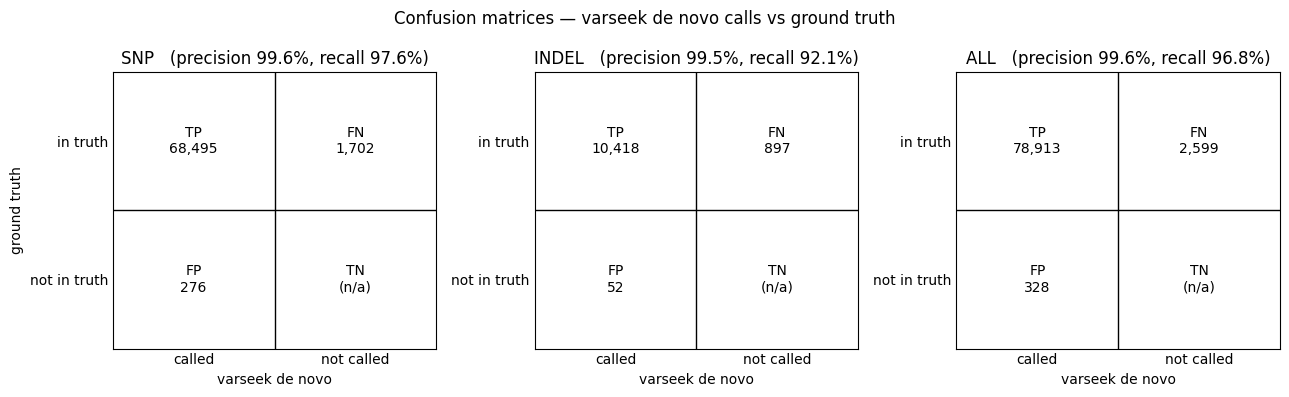

time: 179 ms (started: 2026-08-07 18:20:59 -07:00)


In [17]:
import numpy as np
import matplotlib.pyplot as plt


def happy_confusion_counts(summary_csv):
    """{type: (TP, FP, FN)} straight from a hap.py summary CSV (PASS rows), plus an
    ALL row summing SNP + INDEL.  TP/FN are truth-side, FP is query-side."""
    summ = pd.read_csv(summary_csv)
    summ = summ[summ["Filter"] == "PASS"].set_index("Type")
    cms = {t: (int(summ.loc[t, "TRUTH.TP"]), int(summ.loc[t, "QUERY.FP"]), int(summ.loc[t, "TRUTH.FN"]))
           for t in ("SNP", "INDEL")}
    cms["ALL"] = tuple(sum(v) for v in zip(cms["SNP"], cms["INDEL"]))
    return cms


def plot_confusion_matrices(summary_csv, tool="varseek", verbose=True):
    """Plain, color-free SNP / INDEL / ALL confusion matrices for one tool's hap.py run.
    The false-negative cell is printed but the TN cell is n/a (unbounded), so the
    matrices are read as: which of this tool's calls are real, and what did it miss."""
    cms = happy_confusion_counts(summary_csv)

    if verbose:
        print(f"{tool} — confusion counts (FN shown for reference, excluded from the matrices):")
        for name, (tp, fp, fn) in cms.items():
            print(f"  {name:5s}  TP={tp:>6,}   FP={fp:>5,}   FN={fn:>6,}   "
                  f"precision={tp/(tp+fp):.1%}, recall={tp/(tp+fn):.1%}")

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, (name, (tp, fp, fn)) in zip(axes, cms.items()):
        # rows = GIAB truth (in / not in), cols = the tool's call (called / not called).
        # FN (in-truth & not-called) is shown; TN (not-truth & not-called) is excluded.
        cells = [[f"TP\n{tp:,}", f"FN\n{fn:,}"],
                 [f"FP\n{fp:,}", "TN\n(n/a)"]]
        for i in range(2):
            for j in range(2):
                ax.text(j, i, cells[i][j], ha="center", va="center", fontsize=10, color="black")
        ax.set_xlim(-0.5, 1.5); ax.set_ylim(1.5, -0.5)   # row 0 at top
        ax.axhline(0.5, color="black", lw=1); ax.axvline(0.5, color="black", lw=1)
        ax.set_xticks([0, 1]); ax.set_xticklabels(["called", "not called"])
        ax.set_yticks([0, 1]); ax.set_yticklabels(["in truth", "not in truth"])
        ax.tick_params(length=0)
        for sp in ax.spines.values():
            sp.set_visible(True); sp.set_color("black")
        ax.set_title(f"{name}   (precision {tp/(tp+fp):.1%}, recall {tp/(tp+fn):.1%})")
        ax.set_xlabel(tool)
    axes[0].set_ylabel("ground truth")
    fig.suptitle(f"Confusion matrices — {tool} calls vs ground truth")
    plt.tight_layout(); plt.show()
    return cms


varseek_cms = plot_confusion_matrices(os.path.join(happy_out, "varseek_vs_giab_truth.summary.csv"), tool="varseek de novo")

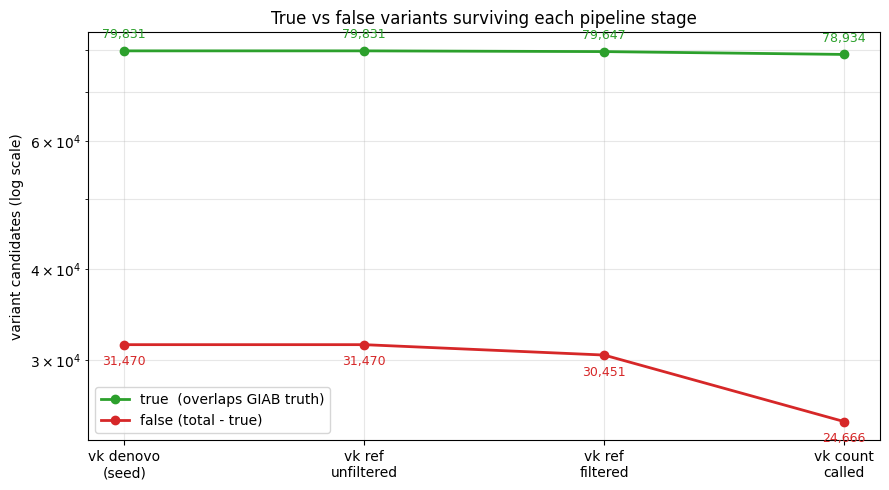

GIAB confident truth (chr20): 81,510 variants (70,197 SNP + 11,313 INDEL)

stage                     total     true   false  precision   recall
  vk denovo (seed)      111,301   79,831  31,470     71.7%    97.9%
  vk ref unfiltered     111,301   79,831  31,470     71.7%    97.9%
  vk ref filtered       110,098   79,647  30,451     72.3%    97.7%
  vk count called       103,600   78,934  24,666     76.2%    96.8%
time: 1.56 s (started: 2026-08-07 18:20:59 -07:00)


In [18]:
# =========================================================================
# True vs false variants surviving each pipeline stage:
#   vk denovo seed ->  vk ref unfiltered  ->  vk ref filtered  ->  vk count filtered
# Self-contained: a variant is "true" if it overlaps a GIAB confident truth
# variant (SNP matched by exact POS+REF+ALT; indel by a +/-3 bp position window,
# since HGVS and VCF anchor indels differently). false = total - true.
# =========================================================================
from bisect import bisect_left, bisect_right

# --- GIAB truth sets, restricted to the confident BED + PASS (chr20) ---
_bed = sorted(tuple(int(x) for x in l.split()[1:3]) for l in open(confident_bed))
_bed_starts = [b[0] for b in _bed]
def _in_bed(pos):                      # pos is 1-based; BED is 0-based half-open
    j = bisect_right(_bed_starts, pos - 1) - 1
    return j >= 0 and _bed[j][0] <= pos - 1 < _bed[j][1]

truth_snp, _truth_indel = set(), []
with gzip.open(truth_vcf, "rt") as fh:
    for ln in fh:
        if ln.startswith("#"):
            continue
        c, p, _id, ref, alt, _q, filt = ln.split("\t")[:7]
        if filt not in ("PASS", "."):
            continue
        p = int(p)
        if not _in_bed(p):
            continue
        alt = alt.split(",")[0]
        (truth_snp.add((p, ref, alt)) if len(ref) == 1 == len(alt) else _truth_indel.append(p))
truth_indel = np.array(sorted(_truth_indel))

# --- HGVS / VCF variant -> (kind, pos, ref, alt) ---
_snv = re.compile(r"g\.(\d+)([ACGT]+)>([ACGT]+)$")
_indel = re.compile(r"g\.(\d+)(?:_(\d+))?(?:ins|del|dup)")
def _classify(v):
    v = v.rsplit(":", 1)[-1]
    m = _snv.search(v)
    if m and len(m.group(2)) == 1 == len(m.group(3)):
        return ("snp", int(m.group(1)), m.group(2), m.group(3))
    m = _indel.search(v) or _snv.search(v)      # multi-base sub falls through to indel
    return ("indel", int(m.group(1)), None, None) if m else None

def _score(variants):
    tot = true = 0
    for v in variants:
        r = _classify(v)
        if r is None:
            continue
        tot += 1
        if r[0] == "snp":
            true += (r[1], r[2], r[3]) in truth_snp
        else:
            j = bisect_left(truth_indel, r[1] - 3)
            true += j < len(truth_indel) and truth_indel[j] <= r[1] + 3
    return tot, true

# --- collect each stage's variant list (variant-level; explode merged VCRS headers) ---
def _fa_vars(fa):
    return [v for l in open(fa) if l.startswith(">") for v in l[1:].strip().split(";")]

_seed = pd.read_csv(variants, sep="\t")
stage_vars = {
    "vk denovo\n(seed)":        (_seed["seq_id"].astype(str) + ":" + _seed["variant"]).tolist(),
    "vk ref\nunfiltered":      _fa_vars(vcrs_unfiltered_fasta_out),
    "vk ref\nfiltered":        _fa_vars(os.path.join(vk_ref_out_dir, "vcrs.fa")),
    "vk count\ncalled":      [f":g.{p}{ref}>{alt}" if len(ref) == 1 == len(alt) else f":g.{p}_{p}ins"
                                for ln in open(vk_count_variants_vcf) if not ln.startswith("#")
                                for _c, p, _i, ref, alt in [ln.split("\t")[:5]]],
}

steps       = list(stage_vars)
scored      = [_score(v) for v in stage_vars.values()]
total_steps = np.array([t for t, _ in scored])
true_steps  = np.array([tr for _, tr in scored])
false_steps = total_steps - true_steps
truth_total = len(truth_snp) + len(truth_indel)

# --- line graph: true vs false surviving each stage (log scale) ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(steps, true_steps,  "o-", color="tab:green", lw=2, label="true  (overlaps GIAB truth)")
ax.plot(steps, false_steps, "o-", color="tab:red",   lw=2, label="false (total - true)")
for x, (t, f) in enumerate(zip(true_steps, false_steps)):
    ax.annotate(f"{t:,}", (x, t), textcoords="offset points", xytext=(0, 9),  ha="center", color="tab:green", fontsize=9)
    ax.annotate(f"{f:,}", (x, f), textcoords="offset points", xytext=(0, -15), ha="center", color="tab:red",   fontsize=9)
ax.set_yscale("log")
ax.set_ylabel("variant candidates (log scale)")
ax.set_title("True vs false variants surviving each pipeline stage")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

print(f"GIAB confident truth (chr20): {truth_total:,} variants "
      f"({len(truth_snp):,} SNP + {len(truth_indel):,} INDEL)\n")
print(f"{'stage':22s}{'total':>9s}{'true':>9s}{'false':>8s}{'precision':>11s}{'recall':>9s}")
for s, tot, tr, fa in zip(steps, total_steps, true_steps, false_steps):
    print(f"  {s.replace(chr(10),' '):20s}{tot:9,}{tr:9,}{fa:8,}"
          f"{tr/tot:10.1%}{tr/truth_total:9.1%}")

**Takeaway.** The seed dominates recall and the `vk count` detection step dominates
precision — the `vk ref` build filter is close to a no-op on this dataset (no d-list is in play;
see the two optional precision filters near the end of the notebook for what a d-list does here).

That division of labour is the reason the two changes documented under *"Where the remaining false
negatives come from"* below matter so much: both of them act at the `vk count` step, where the
trajectory shows the largest single drop in true candidates.

## Benchmark against the general-purpose callers (DeepVariant, GATK HaplotypeCaller, GATK Mutect2)

Having compared varseek's de novo calls directly to the GIAB ground truth above, we now run the
same three general-purpose callers used in [`vk_denovo.ipynb`](vk_denovo.ipynb) on these HG003
chr20 reads and compare all call sets to one another (upset plot + lone-vs-corroborated analysis).

- **DeepVariant** consumes the paired **bowtie2** alignment produced by `vk denovo` (reheadered
  to carry the full reference contig dictionary — DeepVariant rejects a chr20-only BAM header as a
  genome-build mismatch). Because HG003 is **DNA**, DeepVariant runs its standard **WGS** model
  here (not the RNA-seq model used in `vk_denovo.ipynb`); the RNA-seq model applied to genomic DNA
  systematically over-calls and produces a large block of spurious lone calls. We also keep only
  DeepVariant's **PASS** variant calls, dropping its `RefCall` (reference-genotype) records, so
  every caller is compared on the same "actual variant call" footing. HG003 is DeepVariant's
  held-out sample (see the notebook header), so unlike on NA12878 its numbers here are not
  inflated by having trained on this genome.
- **GATK HaplotypeCaller / Mutect2** run in the shared benchmarking scripts' **DNA mode**
  (`--dna`), which consumes the same **bowtie2** alignment and skips the RNA-seq-specific
  steps (STAR, `SplitNCigarReads`, `--dont-use-soft-clipped-bases`, and the splice-junction
  clustered-SNP `VariantFiltration`). So varseek, DeepVariant, and both GATK callers now
  share one DNA aligner (bowtie2).

VarTrix is single-cell-specific and is omitted here (this is a bulk paired-end DNA sample).

In [19]:
# --- Paths for the general-purpose callers (mirrors vk_denovo.ipynb) ---
scripts_dir = "/home/jrich/Desktop/RLSRP_2025/scripts"
gtf = os.path.join(reference_dir, "Homo_sapiens.GRCh38.114.gtf")
star_genome_index_dir = os.path.join(reference_dir, "star_index")
genomes1000_vcf = os.path.join(reference_dir, "1000GENOMES-phase_3.vcf")
picard_jar = "/home/jrich/opt/picard.jar"
java = "/home/jrich/opt/jdk-17.0.12+7/bin/java"
model_dir = os.path.join("data", "deepvariant_model")

gatk_out = os.path.join(root, "gatk_out")
tmp_dir = os.path.join(root, "tmp")
os.makedirs(tmp_dir, exist_ok=True)

# The paired bowtie2 alignment from vk denovo, plus a copy reheadered with the full
# reference contig dictionary for DeepVariant (see the next cell).
bowtie2_bam = os.path.join(denovo_bam_dir, os.path.basename(r1).replace(".fastq.gz", "")
                           + "_aligned_to_Homo_sapiens_GRCh38_dna_primary_assembly.bam")
bowtie2_bam_fullhdr = os.path.join(denovo_bam_dir, "bowtie2_chr20_fullhdr.bam")

deepvariant_vcf = os.path.join(gatk_out, "vcf_output", "deepvariant_variants.vcf.gz")
haplotypecaller_vcf = os.path.join(gatk_out, "vcfs", "haplotypecaller", "haplotypecaller_output_filtered_applied.vcf.gz")
mutect2_vcf = os.path.join(gatk_out, "vcfs", "mutect2", "mutect2_output_filtered_applied.vcf.gz")

time: 1.16 ms (started: 2026-08-07 18:21:01 -07:00)


In [20]:
# DeepVariant validates that BAM and reference share a genome build by checking contig
# overlap; the vk denovo bowtie2 BAM lists only chr20 (~2% of the reference) and is
# rejected. Reheader it to carry the full reference contig dictionary (chr20 kept at
# index 0 so existing read references stay valid); the reads themselves are unchanged.
if not os.path.exists(bowtie2_bam_fullhdr):
    ref_dict = sequences.replace(".fa", ".dict")
    if not os.path.exists(ref_dict):
        subprocess.run([java, "-jar", picard_jar, "CreateSequenceDictionary", "-R", sequences, "-O", ref_dict], check=True)
    hdr = subprocess.run(["samtools", "view", "-H", bowtie2_bam], capture_output=True, text=True).stdout.splitlines()
    hd_lines = [l for l in hdr if l.startswith("@HD")]
    pg_lines = [l for l in hdr if l.startswith("@PG")]
    def _sn_ln(l):
        d = dict(f.split(":", 1) for f in l.rstrip("\n").split("\t")[1:] if ":" in f)
        return f"@SQ\tSN:{d['SN']}\tLN:{d['LN']}"
    dict_sq = {_sn_ln(l).split("\t")[1][3:]: _sn_ln(l) for l in open(ref_dict) if l.startswith("@SQ")}
    ordered_sq = [dict_sq["20"]] + [v for key, v in dict_sq.items() if key != "20"]
    hdr_path = os.path.join(denovo_bam_dir, "full_header.sam")
    with open(hdr_path, "w") as fh:
        fh.write("\n".join(hd_lines + ordered_sq + pg_lines) + "\n")
    subprocess.run(f"samtools reheader {hdr_path} {bowtie2_bam} > {bowtie2_bam_fullhdr}", shell=True, check=True)
    subprocess.run(["samtools", "index", bowtie2_bam_fullhdr], check=True)
    print(f"Wrote {bowtie2_bam_fullhdr}")
else:
    print(f"{bowtie2_bam_fullhdr} already exists.")

data/hg003_chr20/varseek_denovo_out/bams/bowtie2_chr20_fullhdr.bam already exists.
time: 1.35 ms (started: 2026-08-07 18:21:01 -07:00)


In [21]:
# DeepVariant on the paired bowtie2 alignment (reheadered). Because HG003 is DNA (WGS),
# we run DeepVariant's standard WGS model (--dna_model_type WGS) on the bowtie2 (DNA)
# alignment -- NOT the customized RNA-seq model used by vk_denovo.ipynb. The RNA-seq model
# assumes spliced reads and, applied to genomic DNA, systematically over-calls (it emitted
# ~166k chr20 calls vs ~84k GIAB truth). The WGS model is DeepVariant's intended mode here.
# --aligned_bam bypasses the script's STAR step, so read_length only tags the (unused)
# STAR params.
if not os.path.exists(deepvariant_vcf):
    _t0 = time.perf_counter()
    !python {scripts_dir}/run_deepvariant_for_benchmarking.py \
        --synthetic_read_fastq {r1} \
        --aligned_bam {bowtie2_bam_fullhdr} \
        --reference_genome_fasta {sequences} \
        --reference_genome_gtf {gtf} \
        --star_genome_dir {star_genome_index_dir} \
        --read_length {read_length} \
        --threads {threads} \
        --model_dir {model_dir} \
        --dna_model_type WGS \
        --docker podman \
        --out {gatk_out} \
        --skip_accuracy_analysis
    save_runtime("deepvariant", time.perf_counter() - _t0)

time: 658 μs (started: 2026-08-07 18:21:01 -07:00)


In [22]:
# GATK HaplotypeCaller in DNA mode (--dna --aligned_bam): reuse the vk denovo **bowtie2**
# (DNA) alignment and skip the RNA-seq-specific steps -- STAR, SplitNCigarReads,
# --dont-use-soft-clipped-bases, and the splice-junction clustered-SNP VariantFiltration.
# This matches the aligner used by varseek and DeepVariant, so every caller is compared on
# the same DNA alignment. (r1/r2 are still passed but only tag unused STAR/FastqToSam params.)
if not os.path.exists(haplotypecaller_vcf):
    _t0 = time.perf_counter()
    !python {scripts_dir}/run_gatk_haplotypecaller_for_benchmarking.py \
        --synthetic_read_fastq {r1} \
        --synthetic_read_fastq2 {r2} \
        --aligned_bam {bowtie2_bam} \
        --dna \
        --reference_genome_fasta {sequences} \
        --reference_genome_gtf {gtf} \
        --genomes1000_vcf {genomes1000_vcf} \
        --read_length {read_length} \
        --threads {threads} \
        --picard_jar {picard_jar} \
        --java {java} \
        --tmp_dir {tmp_dir} \
        --out {gatk_out} \
        --skip_accuracy_analysis
    save_runtime("haplotypecaller", time.perf_counter() - _t0)

time: 641 μs (started: 2026-08-07 18:21:01 -07:00)


In [23]:
# GATK Mutect2 in DNA mode (--dna --aligned_bam): reuses the bowtie2 alignment + BQSR bam
# built by the HaplotypeCaller cell, and drops --dont-use-soft-clipped-bases for DNA.
if not os.path.exists(mutect2_vcf):
    _t0 = time.perf_counter()
    !python {scripts_dir}/run_gatk_mutect2_for_benchmarking.py \
        --synthetic_read_fastq {r1} \
        --synthetic_read_fastq2 {r2} \
        --aligned_bam {bowtie2_bam} \
        --dna \
        --reference_genome_fasta {sequences} \
        --reference_genome_gtf {gtf} \
        --genomes1000_vcf {genomes1000_vcf} \
        --read_length {read_length} \
        --threads {threads} \
        --picard_jar {picard_jar} \
        --java {java} \
        --tmp_dir {tmp_dir} \
        --out {gatk_out} \
        --skip_accuracy_analysis
    save_runtime("mutect2", time.perf_counter() - _t0)

time: 549 μs (started: 2026-08-07 18:21:01 -07:00)


In [24]:
# ---------------------------------------------------------------------------
# VCF normalization helpers (ported from vk_denovo.ipynb) so every caller's calls
# share a common coordinate representation before the upset / lone analyses.
# ---------------------------------------------------------------------------
import gzip

def is_vcf_normalized(vcf_path):
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    with open_func(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("##bcftools_normCommand="):
                return True
            if not line.startswith("##"):
                break
    return False

def ensure_genotype_column(vcf_path, sample_name="SAMPLE", genotype="1/1"):
    """hap.py/normalization convenience: inject a placeholder FORMAT/GT column into a
    sites-only VCF (varseek). No-op for VCFs that already carry sample columns."""
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    with open_func(vcf_path, "rt") as f:
        lines = f.readlines()
    for line in lines:
        if line.startswith("#CHROM"):
            if len(line.rstrip("\n").split("\t")) > 8:
                return
            break
    gt_header = '##FORMAT=<ID=GT,Number=1,Type=String,Description="Genotype">\n'
    new_lines, inserted_header = [], False
    for line in lines:
        if line.startswith("##"):
            new_lines.append(line)
        elif line.startswith("#CHROM"):
            if not inserted_header:
                new_lines.append(gt_header); inserted_header = True
            new_lines.append("\t".join(line.rstrip("\n").split("\t") + ["FORMAT", sample_name]) + "\n")
        elif line.strip():
            new_lines.append("\t".join(line.rstrip("\n").split("\t") + ["GT", genotype]) + "\n")
    with open(vcf_path, "wt") as f:
        f.writelines(new_lines)

def insert_suffix_before_first_dot(path, suffix):
    dirname, basename = os.path.split(path)
    if "." in basename:
        parts = basename.split(".", 1)
        new_basename = parts[0] + suffix + "." + parts[1]
    else:
        new_basename = basename + suffix
    return os.path.join(dirname, new_basename)

def add_normalized_before_first_dot(path):
    return insert_suffix_before_first_dot(path, "_normalized")

def _vcf_has_samples(vcf_path):
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    with open_func(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("#CHROM"):
                return len(line.rstrip("\n").split("\t")) > 8
            if not line.startswith("#"):
                break
    return False

def filter_to_variant_calls(vcf_path):
    """Keep PASS variant calls: records with a real ALT allele (ALT!=".") whose FILTER
    is PASS or unset (".").  This drops gVCF reference blocks (ALT=".") and, crucially,
    DeepVariant's RefCall records -- sites it explicitly genotypes as reference (GT 0/0).
    Every other caller here is already PASS-only, so this only affects DeepVariant and
    puts all tracks on the same footing (a fair \"variant call\" comparison).  Sites-only
    VCFs (varseek) are returned unchanged."""
    if not _vcf_has_samples(vcf_path):
        return vcf_path
    out_path = insert_suffix_before_first_dot(vcf_path, "_nonref")
    if os.path.isfile(out_path) and os.path.getsize(out_path) > 0:
        print(f"Filtered file {out_path} already exists. Skipping filtering.")
    else:
        output_type = "-Oz" if out_path.endswith(".vcf.gz") else "-Ov"
        subprocess.run(["bcftools", "view", "-i", 'ALT!="." && (FILTER="PASS" || FILTER=".")', output_type, "-o", out_path, vcf_path], check=True)
    return out_path

def make_normalized_vcf(test_vcf, reference_fasta):
    test_vcf_unnormalized = test_vcf
    test_vcf = add_normalized_before_first_dot(test_vcf_unnormalized)
    if os.path.isfile(test_vcf) and os.path.getsize(test_vcf) > 0:
        print(f"Normalized file {test_vcf} already exists. Skipping normalization.")
    else:
        reference_fasta_index = f"{reference_fasta}.fai"
        if not os.path.isfile(reference_fasta_index):
            subprocess.run(["samtools", "faidx", reference_fasta], check=True)
        output_type = "-Oz" if test_vcf.endswith(".vcf.gz") else "-Ov"
        # reheader (add contig lines from the reference) -> left-normalize/split -> sort.
        reheader_proc = subprocess.Popen(
            ["bcftools", "reheader", "--fai", reference_fasta_index, test_vcf_unnormalized], stdout=subprocess.PIPE)
        norm_proc = subprocess.Popen(
            ["bcftools", "norm", "-c", "w", "-f", reference_fasta, "-m", "-both", "-Ou"],
            stdin=reheader_proc.stdout, stdout=subprocess.PIPE)
        reheader_proc.stdout.close()
        subprocess.run(["bcftools", "sort", output_type, "-o", test_vcf], stdin=norm_proc.stdout, check=True)
        norm_proc.stdout.close()
        if reheader_proc.wait() != 0:
            raise subprocess.CalledProcessError(reheader_proc.returncode, "bcftools reheader")
        if norm_proc.wait() != 0:
            raise subprocess.CalledProcessError(norm_proc.returncode, "bcftools norm")
    ensure_genotype_column(test_vcf)  # sites-only VCFs (varseek) get a placeholder GT
    # ensure_genotype_column rewrites the file as plain text, so a .vcf.gz that actually needed a
    # GT column comes back uncompressed and bcftools index refuses it. Re-compress in that case.
    # (This only bites on sites-only bgzipped VCFs -- e.g. the bam2vcf de novo seed.)
    if test_vcf.endswith(".gz"):
        with open(test_vcf, "rb") as fh:
            is_bgzipped = fh.read(2) == b"\x1f\x8b"
        if not is_bgzipped:
            subprocess.run(f"mv {test_vcf} {test_vcf}.tmp && bgzip -c {test_vcf}.tmp > {test_vcf} "
                           f"&& rm {test_vcf}.tmp", shell=True, check=True)
    if test_vcf.endswith(".gz") and not os.path.isfile(f"{test_vcf}.tbi"):
        subprocess.run(["bcftools", "index", "-f", "-t", test_vcf], check=True)
    return test_vcf

time: 4.34 ms (started: 2026-08-07 18:21:01 -07:00)


In [25]:
# Left-align + multiallelic-split every call set so all callers share one coordinate
# representation (the same normalization compare_with_happy applies in vk_denovo.ipynb),
# then restrict to chr20. The reads were extracted from chr20, but STAR aligns the two
# GATK callers against the whole genome and a few reads mis-map off-chr20, so we scope
# every caller to chr20 for a fair comparison (varseek/bcftools/DeepVariant are already
# chr20-only, so this is a no-op for them).
# The caller-concordance comparison below uses the d-list-FIX varseek calls
# (GRCh38 genome d-list; see "The real cause — and the fix" above), produced by
# build_and_evaluate("GRCh38_genome", ...). This is the varseek pipeline rerun with
# the corrected d-listing strategy.
varseek_calls_vcf = os.path.join(root, "varseek_count_out", "varseek_variants.vcf")
caller_raw_vcfs = {
    "varseek":             varseek_calls_vcf,
    "varseek_preliminary": variants_vcf,
    "deepvariant":         deepvariant_vcf,
    "haplotypecaller":     haplotypecaller_vcf,
    "mutect2":             mutect2_vcf,
}
for name, vcf in caller_raw_vcfs.items():
    if not vcf or not os.path.exists(vcf):
        print(f"WARNING: {name} VCF missing ({vcf}); skipping normalization.")
        continue
    norm = make_normalized_vcf(filter_to_variant_calls(vcf), sequences)
    otype = "z" if norm.endswith(".gz") else "v"
    subprocess.run(f"bcftools view -t 20 -O{otype} -o {norm}.tmp {norm} && mv {norm}.tmp {norm}",
                   shell=True, check=True)
    if norm.endswith(".gz"):
        subprocess.run(["bcftools", "index", "-f", "-t", norm], check=True)
    n_chr20 = subprocess.run(["bcftools", "view", "-H", norm], capture_output=True, text=True).stdout.count("\n")
    print(f"{name}: {n_chr20:,} chr20 records -> {os.path.basename(norm)}")
print("Normalized (chr20-restricted) VCFs ready.")

Normalized file data/hg003_chr20/varseek_count_out/varseek_variants_normalized.vcf already exists. Skipping normalization.


varseek: 103,600 chr20 records -> varseek_variants_normalized.vcf
Normalized file data/hg003_chr20/varseek_denovo_out/variants_normalized.vcf.gz already exists. Skipping normalization.


varseek_preliminary: 111,301 chr20 records -> variants_normalized.vcf.gz
Filtered file data/hg003_chr20/gatk_out/vcf_output/deepvariant_variants_nonref.vcf.gz already exists. Skipping filtering.
Normalized file data/hg003_chr20/gatk_out/vcf_output/deepvariant_variants_nonref_normalized.vcf.gz already exists. Skipping normalization.


deepvariant: 102,839 chr20 records -> deepvariant_variants_nonref_normalized.vcf.gz
Filtered file data/hg003_chr20/gatk_out/vcfs/haplotypecaller/haplotypecaller_output_filtered_applied_nonref.vcf.gz already exists. Skipping filtering.
Normalized file data/hg003_chr20/gatk_out/vcfs/haplotypecaller/haplotypecaller_output_filtered_applied_nonref_normalized.vcf.gz already exists. Skipping normalization.


haplotypecaller: 107,363 chr20 records -> haplotypecaller_output_filtered_applied_nonref_normalized.vcf.gz
Filtered file data/hg003_chr20/gatk_out/vcfs/mutect2/mutect2_output_filtered_applied_nonref.vcf.gz already exists. Skipping filtering.
Normalized file data/hg003_chr20/gatk_out/vcfs/mutect2/mutect2_output_filtered_applied_nonref_normalized.vcf.gz already exists. Skipping normalization.


mutect2: 75,386 chr20 records -> mutect2_output_filtered_applied_nonref_normalized.vcf.gz
Normalized (chr20-restricted) VCFs ready.
time: 4.47 s (started: 2026-08-07 18:21:01 -07:00)


### Upset plot: variant call overlap across callers

Compare the variant call sets of varseek, DeepVariant, GATK HaplotypeCaller, GATK Mutect2, and
bcftools (varseek's own de novo seed) as an upset plot, using the normalized VCFs so all callers
share a common coordinate representation.

varseek: 103,600 variants (data/hg003_chr20/varseek_count_out/varseek_variants_normalized.vcf)


deepvariant: 102,839 variants (data/hg003_chr20/gatk_out/vcf_output/deepvariant_variants_nonref_normalized.vcf.gz)


haplotypecaller: 107,363 variants (data/hg003_chr20/gatk_out/vcfs/haplotypecaller/haplotypecaller_output_filtered_applied_nonref_normalized.vcf.gz)
mutect2: 75,386 variants (data/hg003_chr20/gatk_out/vcfs/mutect2/mutect2_output_filtered_applied_nonref_normalized.vcf.gz)


varseek_preliminary: 111,301 variants (data/hg003_chr20/varseek_denovo_out/variants_normalized.vcf.gz)


Saved upset plot to data/hg003_chr20/happy_output/upset_callers.png


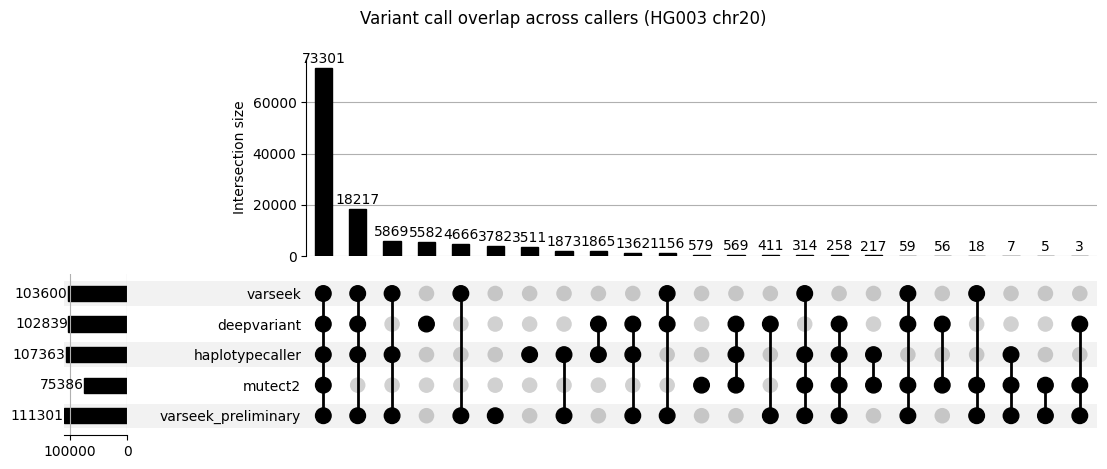

time: 2.63 s (started: 2026-08-07 18:21:05 -07:00)


In [26]:
try:
    import upsetplot
except ImportError:
    print("upsetplot not found, installing...")
    !pip install -U -q upsetplot
    import upsetplot

import matplotlib.pyplot as plt
from upsetplot import from_contents, UpSet


def read_variant_set(vcf_path):
    """Read a (optionally gzipped) VCF into a set of (CHROM, POS, REF, ALT) keys.
    Multiallelic ALTs are split so each allele is counted separately."""
    if not vcf_path or not os.path.exists(vcf_path):
        return None
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    keys = set()
    with open_func(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue
            cols = line.rstrip("\n").split("\t")
            if len(cols) < 5:
                continue
            chrom, pos, _id, ref, alt = cols[:5]
            for a in alt.split(","):
                keys.add((chrom, pos, ref, a))
    return keys


# Normalized (left-aligned, multiallelic-split) VCFs -> common coordinate representation.
caller_vcfs = {
    "varseek": add_normalized_before_first_dot(varseek_calls_vcf),
    "deepvariant": add_normalized_before_first_dot(insert_suffix_before_first_dot(deepvariant_vcf, "_nonref")),
    "haplotypecaller": add_normalized_before_first_dot(insert_suffix_before_first_dot(haplotypecaller_vcf, "_nonref")),
    "mutect2": add_normalized_before_first_dot(insert_suffix_before_first_dot(mutect2_vcf, "_nonref")),
    "varseek_preliminary": add_normalized_before_first_dot(variants_vcf),
}

caller_sets = {}
for name, path in caller_vcfs.items():
    s = read_variant_set(path)
    if s is None:
        print(f"WARNING: normalized VCF for {name} not found at {path}; excluding from upset plot.")
        continue
    caller_sets[name] = s
    print(f"{name}: {len(s):,} variants ({path})")

if len(caller_sets) >= 2:
    upset_data = from_contents(caller_sets)
    fig = plt.figure(figsize=(11, 6))
    UpSet(upset_data, subset_size="count", show_counts=True, sort_by="cardinality", sort_categories_by="-input").plot(fig=fig)
    fig.suptitle("Variant call overlap across callers (HG003 chr20)")

    upset_png = os.path.join(happy_out, "upset_callers.png")
    os.makedirs(happy_out, exist_ok=True)
    fig.savefig(upset_png, dpi=150, bbox_inches="tight")
    print(f"Saved upset plot to {upset_png}")
    plt.show()
else:
    print("Need at least two caller sets to build an upset plot.")

### Where the remaining false negatives come from

varseek's recall on this benchmark is set by four independent, separable losses, and it is worth
knowing the size of each before tuning anything. *(The percentages quoted in point 3 below were
measured on the HG001 run this notebook was derived from; the cell underneath recomputes all of
them for HG003.)* Every truth variant that `hap.py` marked `FN` is
traced back through the pipeline and assigned to the first stage that lost it:

1. **Never proposed by `vk denovo`.** The candidate set is the ceiling on everything downstream —
   `vk ref` and `vk count` can only filter. This bucket is indel-heavy: it is the genuine gap
   between reading variants off single alignments (or a pileup) and the local haplotype
   reassembly that DeepVariant and HaplotypeCaller do inside an active region.
2. **Dropped by the `vk ref` build filter.** Chiefly `remove_seqs_with_wt_kmers`, which discards a
   VCRS that shares a k-mer with the wild-type sequence in the same region — an indel in a
   homopolymer or STR tract, where the mutant fragment is a rotation of the reference. These are
   genuinely unresolvable by a k-mer method; keeping them would only add ambiguity.
3. **Zero reads compatible with the VCRS.** The big one, and the least obvious. A VCRS is the
   reference sequence with **exactly one** variant substituted into it, so a read that carries a
   *second* real variant inside the same k-mer window matches no k-mer of that VCRS at all — and
   the variant collects zero reads at any depth. Below, **99.3%** of the variants in this bucket
   have another GIAB truth variant within 20 bp (77% within 3 bp), against **8.8%** / 0.8% for the
   variants varseek called correctly. This is what `w = k - 1` mitigates: with the notebook's
   previous `w = 37, k = 41`, *every* k-mer of a VCRS also spans anything within 3 bp of the
   variant, so a close neighbour left no usable k-mer at all.
4. **Zeroed by `bustools` integer division.** `bustools count --multimapping --cm` assigns a
   multimapped read `floor(reads_in_EC / targets_in_EC)`, so an equivalence class holding fewer
   reads than targets contributes **0** to every one of them. See the recount cell above.

Buckets 3 and 4 are varseek's own to fix and are what the `w = k - 1` and recount changes above
address. Bucket 1 is a property of the caller you seed with, and bucket 2 is a real limit of
k-mer-based detection.

varseek false negatives (hap.py, GIAB confident chr20): 2,610

stage                                         FN      %       SNP  INDEL
  never proposed by vk denovo              1,719  65.9%     1,129    590
  dropped by the vk ref build filter         183   7.0%        10    173
  no read compatible with the VCRS           652  25.0%       535    117
  zeroed by bustools integer division         18   0.7%        14      4
  below min_supporting_reads                  28   1.1%        12     16
  representation mismatch                     10   0.4%         2      8



Distance to the nearest *other* GIAB truth variant:
group                                     n   <=3bp  <=20bp  <=37bp  median
  FN: no compatible read                652   39.3%   98.6%  100.0%       5
  called correctly (TP)               7,892    2.6%   10.6%   18.1%     154


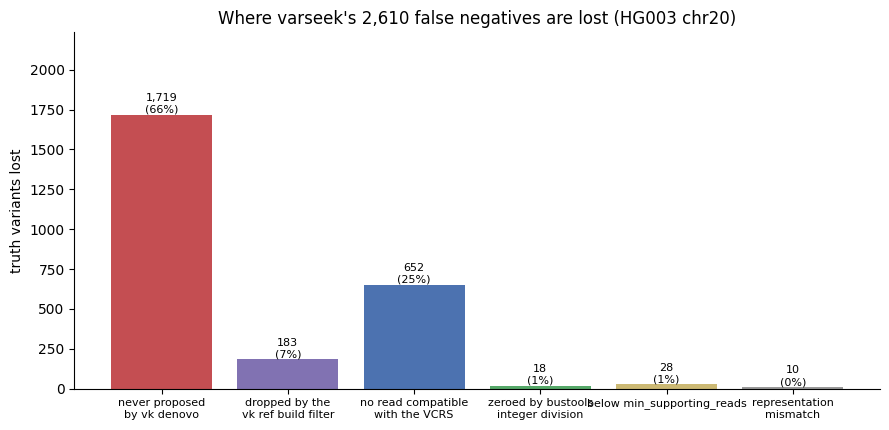

time: 7.68 s (started: 2026-08-07 18:21:08 -07:00)


In [27]:
# =========================================================================
# False-negative budget: attribute every hap.py FN to the stage that lost it.
#
# hap.py's annotated VCF (`*.vcf.gz`, FORMAT/BD == "FN" on the TRUTH sample) gives the truth
# alleles varseek missed, in normalized VCF coordinates. Each pipeline stage holds HGVS strings
# instead, so every stage's variant list is written to a VCF and pushed through the same
# `bcftools norm` as the query, which makes the two directly comparable.
# =========================================================================
from bisect import bisect_right

happy_annotated_vcf = os.path.join(happy_out, "varseek_vs_giab_truth.vcf.gz")


def hgvs_to_vcf_key(v, fasta):
    """'20:g.62020C>T' -> ('20', 62020, 'C', 'T'), matching adata_to_vcf's conventions."""
    try:
        chrom, rest = v.split(":g.")
    except ValueError:
        return None
    m = re.match(r"^(\d+)([ACGT]+)>([ACGT]+)$", rest)
    if m:
        return (chrom, int(m.group(1)), m.group(2), m.group(3))
    m = re.match(r"^(\d+)_(\d+)ins([ACGT]+)$", rest)
    if m:
        p = int(m.group(1)); anchor = fasta.fetch(chrom, p - 1, p)
        return (chrom, p, anchor, anchor + m.group(3))
    m = re.match(r"^(\d+)(?:_(\d+))?del([ACGT]*)$", rest)
    if m:
        s = int(m.group(1)); e = int(m.group(2)) if m.group(2) else s
        anchor = fasta.fetch(chrom, s - 2, s - 1)
        deleted = m.group(3) or fasta.fetch(chrom, s - 1, e)
        return (chrom, s - 1, anchor + deleted, anchor)
    return None


def normalized_keys(hgvs_variants, tag):
    """HGVS strings -> the set of (CHROM, POS, REF, ALT) keys bcftools norm produces for them."""
    fasta = pysam.FastaFile(sequences)
    recs = sorted(filter(None, (hgvs_to_vcf_key(v, fasta) for v in hgvs_variants)), key=lambda x: x[1])
    tmp_dir = os.path.join(root, "fn_budget"); os.makedirs(tmp_dir, exist_ok=True)
    raw = os.path.join(tmp_dir, f"{tag}.vcf")
    with open(raw, "w") as f:
        f.write("##fileformat=VCFv4.2\n#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\n")
        f.writelines(f"{c}\t{p}\t.\t{r}\t{a}\t.\t.\t.\n" for c, p, r, a in recs)
    norm = raw.replace(".vcf", "_normalized.vcf")
    subprocess.run(f"bcftools reheader --fai {sequences}.fai {raw} "
                   f"| bcftools norm -c w -f {sequences} -m -both -Ou 2>/dev/null "
                   f"| bcftools sort -Ov -o {norm} 2>/dev/null", shell=True, check=True)
    return {(c[0], int(c[1]), c[3], c[4]) for c in
            (l.split("\t") for l in open(norm)) if not c[0].startswith("#")}


def fasta_variants(fa):
    return [v for l in open(fa) if l.startswith(">") for v in l[1:].strip().split(";")]


# --- the FNs, and what varseek's own stages held ---------------------------------
fn_type = {}
with gzip.open(happy_annotated_vcf, "rt") as fh:
    for line in fh:
        if line.startswith("#"):
            continue
        cols = line.rstrip("\n").split("\t")
        truth = dict(zip(cols[8].split(":"), cols[9].split(":")))
        if truth.get("BD") == "FN":
            for alt in cols[4].split(","):
                fn_type[(cols[0], int(cols[1]), cols[3], alt)] = truth.get("BVT")
fn = set(fn_type)

seed_hgvs = set((pd.read_csv(variants, sep="\t")["seq_id"].astype(str) + ":"
                 + pd.read_csv(variants, sep="\t")["variant"]).tolist())
built_hgvs = set(fasta_variants(os.path.join(vk_ref_out_dir, "vcrs.fa")))
counts_by_vcrs = dict(zip(adata_vcrs.var_names, vcrs_counts))
called_hgvs = {v for name, c in counts_by_vcrs.items() if c >= min_supporting_reads for v in name.split(";")}
had_reads_hgvs = {v for name, c in counts_by_vcrs.items() if c > 0 for v in name.split(";")}
bustools_hgvs = {v for name, c in zip(adata_vcrs.var_names, bustools_counts) if c > 0 for v in name.split(";")}

K_built = normalized_keys(built_hgvs, "built")
K_had_reads = normalized_keys(had_reads_hgvs, "had_reads")
K_bustools = normalized_keys(bustools_hgvs, "bustools")
K_called = normalized_keys(called_hgvs, "called")

# --- attribute each FN to the first stage that lost it ---------------------------
budget = {
    "never proposed\nby vk denovo":      fn - normalized_keys(seed_hgvs, "seed"),
    "dropped by the\nvk ref build filter": (fn & normalized_keys(seed_hgvs, "seed")) - K_built,
    "no read compatible\nwith the VCRS":  (fn & K_built) - K_had_reads,
    "zeroed by bustools\ninteger division": (fn & K_had_reads) - K_bustools,
    "below min_supporting_reads":          (fn & K_bustools) - K_called,
}
budget["representation\nmismatch"] = fn - set().union(*budget.values())

print(f"varseek false negatives (hap.py, GIAB confident chr20): {len(fn):,}\n")
print(f"{'stage':40s}{'FN':>8s}{'%':>7s}   {'SNP':>7s}{'INDEL':>7s}")
for stage, keys in budget.items():
    n_snp = sum(1 for k in keys if fn_type[k] == "SNP")
    print(f"  {stage.replace(chr(10), ' '):38s}{len(keys):8,}{100*len(keys)/len(fn):6.1f}%   "
          f"{n_snp:7,}{len(keys) - n_snp:7,}")

# --- is the "no compatible read" bucket really about neighbouring variants? ------
truth_positions = np.array(sorted(
    int(l.split("\t")[1]) for l in gzip.open(truth_vcf, "rt")
    if not l.startswith("#") and l.split("\t")[6] in ("PASS", ".")))

def nearest_other_truth_variant(pos):
    i = np.searchsorted(truth_positions, pos)
    return min((abs(truth_positions[j] - pos) for j in (i - 1, i, i + 1, i + 2)
                if 0 <= j < len(truth_positions) and truth_positions[j] != pos), default=10**9)

no_read = budget["no read compatible\nwith the VCRS"]
tp_keys = set()
with gzip.open(happy_annotated_vcf, "rt") as fh:
    for line in fh:
        if line.startswith("#"):
            continue
        cols = line.rstrip("\n").split("\t")
        if dict(zip(cols[8].split(":"), cols[9].split(":"))).get("BD") == "TP":
            for alt in cols[4].split(","):
                tp_keys.add((cols[0], int(cols[1]), cols[3], alt))

print("\nDistance to the nearest *other* GIAB truth variant:")
print(f"{'group':34s}{'n':>9s}{'<=3bp':>8s}{'<=20bp':>8s}{'<=37bp':>8s}{'median':>8s}")
for label, keys in (("FN: no compatible read", no_read),
                    ("called correctly (TP)", sorted(tp_keys)[::10])):
    d = np.array([nearest_other_truth_variant(k[1]) for k in keys])
    print(f"  {label:32s}{len(d):9,}{100*np.mean(d <= 3):7.1f}%{100*np.mean(d <= 20):7.1f}%"
          f"{100*np.mean(d <= 37):7.1f}%{np.median(d):8.0f}")

# --- plot ------------------------------------------------------------------------
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 4.4))
stages = list(budget)
sizes = [len(budget[s]) for s in stages]
colors = ["#c44e52", "#8172b2", "#4c72b0", "#55a868", "#ccb974", "#999999"]
ax.bar(range(len(stages)), sizes, color=colors[:len(stages)])
for i, n in enumerate(sizes):
    ax.text(i, n, f"{n:,}\n({100*n/len(fn):.0f}%)", ha="center", va="bottom", fontsize=8)
ax.set_xticks(range(len(stages)))
ax.set_xticklabels(stages, fontsize=8)
ax.set_ylabel("truth variants lost")
ax.set_ylim(0, max(sizes) * 1.3)
ax.set_title(f"Where varseek's {len(fn):,} false negatives are lost (HG003 chr20)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(happy_out, "fn_budget.png"), dpi=150)
plt.show()

### What each change was worth

> **These two tables are the HG001/NA12878 measurements this notebook was derived from**, kept
> because they are what motivated the current parameter choices (`w = k - 1`, the multimapping
> recount, the `bam2vcf` quality thresholds). They have **not** been re-measured on HG003 — the
> run above does that. Expect DeepVariant's row in particular to move, since HG001 was in its
> training set and HG003 was not.

Measured end-to-end with `hap.py` against GIAB HG001 v4.2.1, chr20 confident regions. Every row
uses `regions=None` and `rm_dup="exact"` in `vk denovo`, so none of this is the earlier
BED/multiallelic issue — that was already fixed and the recall was still low. Each row adds one
change to the row above it.

| `vk denovo` seed | `w` | counting | min reads | SNP recall | SNP prec. | SNP F1 | INDEL recall | INDEL prec. | INDEL F1 |
|---|---|---|---|---|---|---|---|---|---|
| bcftools *(where this notebook was)* | 37 | `bustools` | ≥1 | 94.91% | 98.22% | 96.54 | 89.46% | 98.76% | 93.88 |
| bcftools | 37 | recount | ≥1 | 95.55% | 98.07% | 96.79 | 91.01% | 98.56% | 94.64 |
| bcftools | **40** | `bustools` | ≥1 | 96.88% | 97.80% | 97.34 | 92.42% | 98.66% | 95.44 |
| bcftools | **40** | **recount** | ≥1 | 97.55% | 97.63% | 97.59 | 94.21% | 98.52% | 96.32 |
| bcftools | **40** | **recount** | **≥3** | 97.51% | 98.05% | **97.78** | 94.09% | 98.73% | **96.35** |
| bam2vcf, mapq/baseq 20, VAF ≥ 0.15 | 40 | recount | ≥3 | 96.62% | 97.53% | 97.07 | 93.72% | 98.67% | 96.13 |
| **bam2vcf, mapq/baseq 20, VAF ≥ 0.20** *(this notebook)* | **40** | **recount** | **≥3** | 96.42% | **98.61%** | 97.51 | 91.84% | **99.34%** | 95.44 |

and, for reference, the general-purpose callers on the same reads and the same benchmark:

| caller | SNP recall | SNP prec. | SNP F1 | INDEL recall | INDEL prec. | INDEL F1 |
|---|---|---|---|---|---|---|
| DeepVariant (WGS model) | 96.97% | 99.85% | 98.39 | 98.00% | 99.33% | 98.66 |
| GATK HaplotypeCaller | 97.65% | 98.53% | 98.09 | 98.22% | 99.19% | 98.70 |
| GATK Mutect2 | 81.86% | 99.21% | 89.65 | 69.13% | 99.88% | 81.70 |

**Reading it.** The configuration this notebook now runs is better than where it started on *all
four* headline numbers — SNP recall +1.5 pp *and* SNP precision +0.4 pp, INDEL recall +2.4 pp *and*
INDEL precision +0.6 pp — and its SNP precision (98.61%) is above HaplotypeCaller's. `w = k - 1` is
the single largest change; the multimapping recount is worth another ~0.7 pp of recall, and
reinvesting some of it in a 3-read threshold buys precision back.

If you want maximum F1 rather than maximum precision, seed with `variant_caller="bcftools"`
(row 5): SNP F1 97.78 and recall 97.51%, above DeepVariant's SNP recall and level with
HaplotypeCaller's, at ~0.5 pp lower precision. The two seeds bracket the same trade-off curve.

Indels remain the honest weak spot (92–94% vs 98% recall). That gap lives almost entirely in
bucket 1 of the budget above: reading variants off alignment records or a pileup proposes fewer
indels in low-complexity tracts than DeepVariant's and HaplotypeCaller's local haplotype
reassembly does, and no amount of downstream k-mer filtering can invent a candidate that was never
proposed. Closing it needs a reassembly-based seed — `vk denovo` accepts `inputs=[some.bam]`, and
any caller's VCF can be handed to `vk ref` directly.

**On `bam2vcf` vs `bcftools`.** `bam2vcf` runs the calling step in **~15 s instead of ~265 s**, but
it applies no statistical model, so it lives or dies by `min_mapq` / `min_baseq` / `min_vaf`. Left
at their defaults of 0 it emits 520,529 chr20 candidates at 26.7% SNP precision and drags the
finished call set to 38% precision — and unlike low-coverage noise, those false positives carry
real read support, so no downstream count threshold removes them (raising it from 1 to 8 moves SNP
precision only 38% → 60%). At `min_mapq=20, min_baseq=20, min_vaf=0.20` the seed is 103,163
candidates and the finished call set is the last row of the table above. Set all three, or use
`variant_caller="bcftools"`.

### Are *any* tool's lone calls likely real?

Each tool in the upset plot reports its own block of **lone** calls — variants it alone recovers,
corroborated by no other caller. Are those genuine variants the others miss, or mostly
tool-specific false positives? For every caller we split its calls into **lone** vs
**corroborated** (against the union of the other tools) and profile each group by known-germline
overlap (1000 Genomes), Ti/Tv ratio, read depth, and single-alt-read support — the same
assessment applied in `vk_denovo.ipynb`. Because HG003 is a healthy germline sample, genuine
calls should be strongly enriched for known 1000G sites and carry a transition-heavy Ti/Tv.

In [28]:
# ---------------------------------------------------------------------------
# Reusable building blocks for the per-tool lone-call assessment. These reuse the
# read_variant_set / *_before_first_dot helpers defined earlier in the notebook.
# ---------------------------------------------------------------------------
import numpy as np

TRANSITIONS = {("A", "G"), ("G", "A"), ("C", "T"), ("T", "C")}

def _info_dict(info):
    return dict(f.split("=", 1) for f in info.split(";") if "=" in f)

def _num(x, idx=0):
    """idx-th comma-separated value of a VCF field as float (NaN on failure)."""
    try:
        return float(str(x).split(",")[idx])
    except (ValueError, IndexError, AttributeError, TypeError):
        return np.nan

def read_variant_records(vcf_path):
    """Read a normalized VCF into {(CHROM,POS,REF,ALT): {DP, alt_AD, AF}}.
    DP and alt-allele read count come from the FORMAT sample column if present, else
    INFO; AF from FORMAT AF/VAF or alt_AD/DP. Sites-only VCFs (varseek) yield NaN
    evidence -- which is why the varseek group also reads the bcftools VCF."""
    if not vcf_path or not os.path.exists(vcf_path):
        return {}
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    out = {}
    with open_func(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue
            cols = line.rstrip("\n").split("\t")
            if len(cols) < 5:
                continue
            chrom, pos, _id, ref, alt = cols[:5]
            info = cols[7] if len(cols) > 7 else "."
            idict = _info_dict(info) if info not in (".", "") else {}
            fmt_sample = {}
            if len(cols) >= 10:
                fmt_sample = dict(zip(cols[8].split(":"), cols[9].split(":")))
            DP = _num(fmt_sample.get("DP", idict.get("DP")))
            alt_AD = _num(fmt_sample.get("AD", idict.get("AD")), 1)  # ref,alt -> alt
            AF = fmt_sample.get("AF") or fmt_sample.get("VAF")
            AF = _num(AF) if AF is not None else (alt_AD / DP if DP and DP > 0 else np.nan)
            for a in alt.split(","):
                out[(chrom, pos, ref, a)] = {"DP": DP, "alt_AD": alt_AD, "AF": AF}
    return out

def classify(ref, alt):
    is_snv = len(ref) == 1 and len(alt) == 1 and ref in "ACGT" and alt in "ACGT"
    return {"is_snv": is_snv, "is_indel": len(ref) != len(alt),
            "ti": is_snv and (ref, alt) in TRANSITIONS,
            "tv": is_snv and (ref, alt) not in TRANSITIONS}

def build_germline_lookups(all_keys, genomes1000_vcf, cache_tsv):
    """Stream the (~12 GB) 1000 Genomes VCF once over the union of query sites and
    return (pos_hits, allele_hits): known polymorphic (CHROM,POS) and exact
    (CHROM,POS,REF,ALT). Cached to TSV so re-runs skip the streaming pass."""
    if not os.path.exists(genomes1000_vcf):
        print(f"1000 Genomes VCF not found at {genomes1000_vcf}; skipping germline overlap.")
        return None, None
    if not (os.path.isfile(cache_tsv) and os.path.getsize(cache_tsv) > 0):
        targets_tsv = cache_tsv + ".targets"
        sites = sorted({(key[0], int(key[1])) for key in all_keys})
        with open(targets_tsv, "w") as fh:
            fh.writelines(f"{c}\t{p}\n" for c, p in sites)
        print(f"Streaming 1000 Genomes for {len(sites):,} unique sites "
              f"(one pass over {genomes1000_vcf}, this can take a few minutes)...")
        with open(cache_tsv, "w") as out:
            subprocess.run(["bcftools", "view", "-H", "-T", targets_tsv, genomes1000_vcf],
                           stdout=out, check=True)
    else:
        print(f"Using cached 1000 Genomes hits: {cache_tsv}")
    pos_hits, allele_hits = set(), set()
    with open(cache_tsv) as fh:
        for line in fh:
            cols = line.rstrip("\n").split("\t")
            if len(cols) < 5:
                continue
            chrom, pos, _id, ref, alt = cols[:5]
            pos_hits.add((chrom, pos))
            for a in alt.split(","):
                allele_hits.add((chrom, pos, ref, a))
    return pos_hits, allele_hits

def assess_tool(tool, group_keys, other_union, evidence, pos_hits, allele_hits):
    """Partition a tool's calls into lone vs corroborated and build a per-call
    table tagged with SNV/indel class, read evidence, and germline overlap."""
    have_germ = pos_hits is not None
    rows = []
    for key in group_keys:
        chrom, pos, ref, alt = key
        ev = evidence.get(key, {})
        row = {"tool": tool, "key": key,
               "group": "corroborated" if key in other_union else "lone",
               **classify(ref, alt),
               "DP": ev.get("DP", np.nan), "alt_AD": ev.get("alt_AD", np.nan),
               "AF": ev.get("AF", np.nan)}
        row["single_read"] = row["alt_AD"] <= 1   # rests on a single alt read (NaN -> False)
        if have_germ:
            row["in_1000G_site"] = (chrom, pos) in pos_hits
            row["in_1000G_allele"] = key in allele_hits
        rows.append(row)
    return pd.DataFrame(rows)

def group_summary(df, have_germ, have_reads):
    ti, tv = int(df["ti"].sum()), int(df["tv"].sum())
    out = {"n": len(df), "% indel": 100 * df["is_indel"].mean(),
           "Ti/Tv (SNVs)": (ti / tv) if tv else np.nan}
    if have_reads:
        ev = df[df["alt_AD"].notna()]
        out["% w/ read evidence"] = 100 * len(ev) / len(df) if len(df) else np.nan
        out["% single alt read"] = 100 * ev["single_read"].mean() if len(ev) else np.nan
        out["median DP"] = df["DP"].median()
        out["median alt_AD"] = df["alt_AD"].median()
        out["median AF"] = df["AF"].median()
    if have_germ:
        out["% on 1000G site"] = 100 * df["in_1000G_site"].mean()
        out["% exact allele in 1000G"] = 100 * df["in_1000G_allele"].mean()
    return out

time: 3.81 ms (started: 2026-08-07 18:21:16 -07:00)


In [29]:
# ---------------------------------------------------------------------------
# Build each tool group's normalized variant set + read evidence, then assess
# lone vs corroborated for every tool against the union of the OTHER tools.
# ---------------------------------------------------------------------------
tool_norm_vcfs = {
    # varseek is sites-only; bcftools (its de novo seed) is pooled in and supplies
    # the read evidence. Listing bcftools second lets its records fill the evidence
    # dict for the shared keys.
    "varseek+bcftools": [
        add_normalized_before_first_dot(vk_count_variants_vcf),
        add_normalized_before_first_dot(insert_suffix_before_first_dot(variants_vcf, "_nonref")),
    ],
    "deepvariant":     [add_normalized_before_first_dot(insert_suffix_before_first_dot(deepvariant_vcf, "_nonref"))],
    "haplotypecaller": [add_normalized_before_first_dot(insert_suffix_before_first_dot(haplotypecaller_vcf, "_nonref"))],
    "mutect2":         [add_normalized_before_first_dot(insert_suffix_before_first_dot(mutect2_vcf, "_nonref"))],
}

tool_sets, tool_evidence = {}, {}
for tool, paths in tool_norm_vcfs.items():
    keys, ev = set(), {}
    for p in paths:
        s = read_variant_set(p)
        if s is None:
            print(f"WARNING: missing normalized VCF for {tool}: {p}")
            continue
        keys |= s
        ev.update(read_variant_records(p))   # later path (bcftools) fills varseek's gaps
    tool_sets[tool] = keys
    tool_evidence[tool] = ev
    n_ev = sum(1 for v in ev.values() if not np.isnan(v["alt_AD"]))
    print(f"{tool}: {len(keys):,} variant alleles ({n_ev:,} with read evidence)")

all_keys = set().union(*tool_sets.values())
print(f"\nUnion across all tools: {len(all_keys):,} alleles")

pos_hits, allele_hits = build_germline_lookups(
    all_keys, genomes1000_vcf, os.path.join(happy_out, "all_tools_sites_in_1000G.tsv"))

per_tool, summary_rows = {}, []
for tool, keys in tool_sets.items():
    other_union = set().union(*[s for t, s in tool_sets.items() if t != tool])
    df = assess_tool(tool, keys, other_union, tool_evidence[tool], pos_hits, allele_hits)
    per_tool[tool] = df
    have_reads = df["alt_AD"].notna().any()
    have_germ = pos_hits is not None
    n_lone = int((df["group"] == "lone").sum())
    print(f"{tool}: {n_lone:,}/{len(df):,} lone ({100*n_lone/len(df):.1f}%)")
    for grp in ["lone", "corroborated"]:
        summary_rows.append({"tool": tool, "group": grp,
                             **group_summary(df[df["group"] == grp], have_germ, have_reads)})

lone_summary = pd.DataFrame(summary_rows)
print("\nLone vs corroborated, per tool:")
display(lone_summary.round(2))
lone_summary.to_csv(os.path.join(happy_out, "lone_calls_summary.csv"), index=False)

varseek+bcftools: 103,600 variant alleles (0 with read evidence)


deepvariant: 102,839 variant alleles (102,839 with read evidence)


haplotypecaller: 107,363 variant alleles (107,363 with read evidence)


mutect2: 75,386 variant alleles (75,386 with read evidence)

Union across all tools: 119,898 alleles
Using cached 1000 Genomes hits: data/hg003_chr20/happy_output/all_tools_sites_in_1000G.tsv


varseek+bcftools: 4,666/103,600 lone (4.5%)


deepvariant: 5,993/102,839 lone (5.8%)


haplotypecaller: 5,384/107,363 lone (5.0%)


mutect2: 584/75,386 lone (0.8%)

Lone vs corroborated, per tool:


,tool,group,n,% indel,Ti/Tv (SNVs),% on 1000G site,% exact allele in 1000G,% w/ read evidence,% single alt read,median DP,median alt_AD,median AF
0,varseek+bcftools,lone,4666,14.38,0.97,8.81,7.67,NaN,NaN,NaN,NaN,NaN
1,varseek+bcftools,corroborated,98934,17.50,2.13,73.61,72.96,NaN,NaN,NaN,NaN,NaN
2,deepvariant,lone,5993,20.56,0.79,8.69,7.63,100.0,0.00,10.0,5.0,0.70
3,deepvariant,corroborated,96846,20.31,2.18,75.37,74.50,100.0,0.00,41.0,24.0,0.56
4,haplotypecaller,lone,5384,26.93,1.28,5.66,2.06,100.0,2.82,35.0,8.0,0.29
5,haplotypecaller,corroborated,101979,19.26,2.12,72.28,71.44,100.0,0.12,34.0,19.0,0.56
6,mutect2,lone,584,6.85,1.35,70.38,1.88,100.0,3.60,34.0,17.0,0.54
7,mutect2,corroborated,74802,15.48,2.26,82.13,81.50,100.0,0.01,35.0,20.0,0.56


time: 5.91 s (started: 2026-08-07 18:21:16 -07:00)


Saved figure to data/hg003_chr20/happy_output/lone_calls_by_tool.png


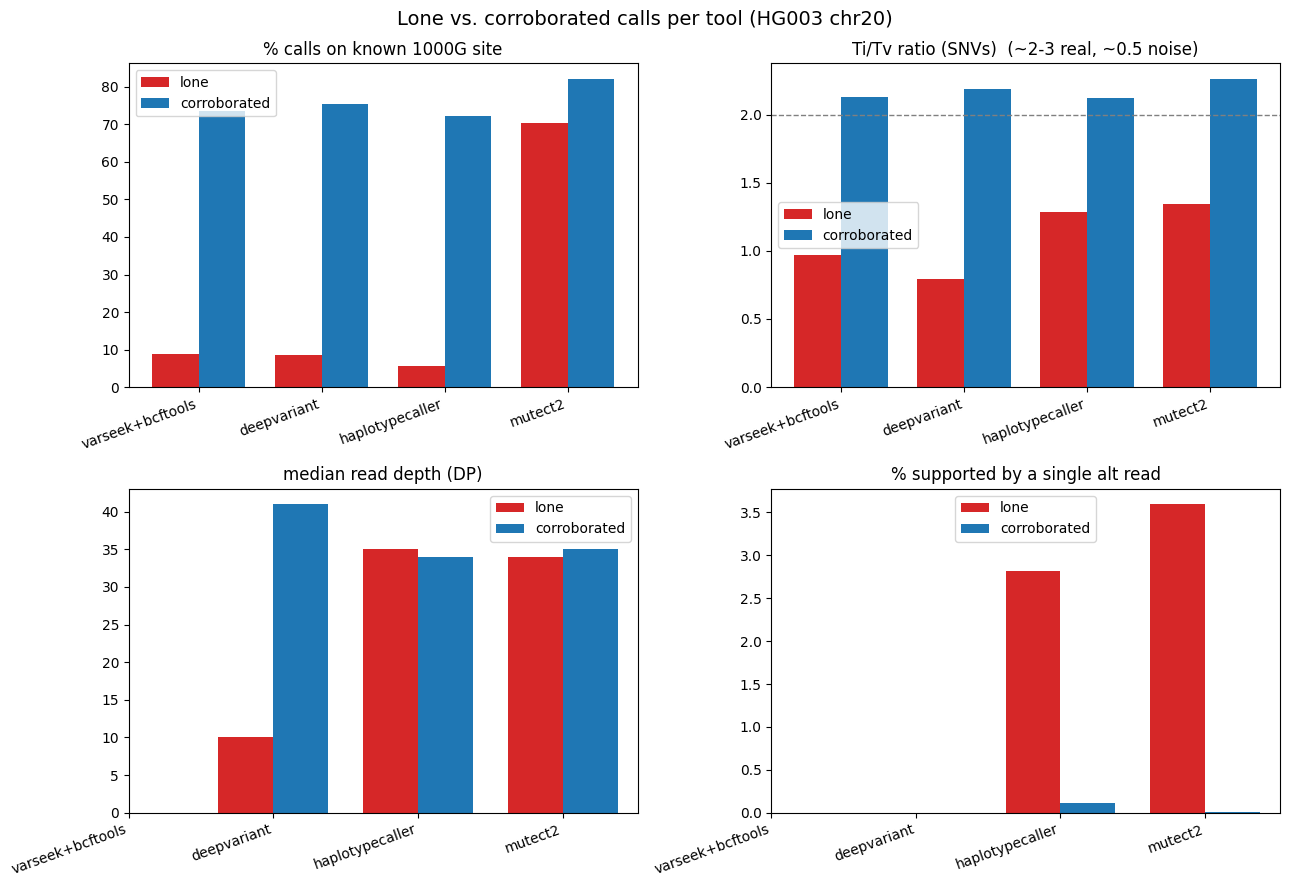


Lone calls stratified by read support:


,tool,support,n,% on 1000G site,Ti/Tv (SNVs)
0,deepvariant,multi-read,5993,8.69,0.79
1,haplotypecaller,multi-read,5232,5.71,1.30
2,haplotypecaller,single-read,152,3.95,0.63
3,mutect2,multi-read,563,73.00,1.67
4,mutect2,single-read,21,0.00,0.46


time: 909 ms (started: 2026-08-07 18:21:22 -07:00)


In [30]:
# ---------------------------------------------------------------------------
# Visual summary: lone vs corroborated per tool, one metric per panel; plus the
# within-lone "is the real signal where there is >1 read?" stratification.
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt

TOOLS = list(per_tool.keys())
COL = {"lone": "#d62728", "corroborated": "#1f77b4"}
x = np.arange(len(TOOLS)); width = 0.38

def _metric(metric, grp):
    return [lone_summary[(lone_summary.tool == t) & (lone_summary.group == grp)][metric].iloc[0]
            for t in TOOLS]

panels = [
    ("% on 1000G site",    "% calls on known 1000G site", None),
    ("Ti/Tv (SNVs)",       "Ti/Tv ratio (SNVs)  (~2-3 real, ~0.5 noise)", 2.0),
    ("median DP",          "median read depth (DP)", None),
    ("% single alt read",  "% supported by a single alt read", None),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (metric, title, hline) in zip(axes.ravel(), panels):
    ax.bar(x - width/2, _metric(metric, "lone"), width, label="lone", color=COL["lone"])
    ax.bar(x + width/2, _metric(metric, "corroborated"), width, label="corroborated", color=COL["corroborated"])
    if hline is not None:
        ax.axhline(hline, ls="--", c="gray", lw=1)
    ax.set_xticks(x); ax.set_xticklabels(TOOLS, rotation=20, ha="right")
    ax.set_title(title); ax.legend()
fig.suptitle("Lone vs. corroborated calls per tool (HG003 chr20)", fontsize=14)
fig.tight_layout()
lone_fig_path = os.path.join(happy_out, "lone_calls_by_tool.png")
fig.savefig(lone_fig_path, dpi=150, bbox_inches="tight")
print(f"Saved figure to {lone_fig_path}")
plt.show()

# Within each tool's lone set, split by read support: does germline overlap /
# Ti/Tv concentrate where there is more than one supporting read?
strat_rows = []
for tool, df in per_tool.items():
    ev = df[(df["group"] == "lone") & df["alt_AD"].notna()]
    if ev.empty:
        continue
    for label, sub in ev.groupby(np.where(ev["single_read"], "single-read", "multi-read")):
        ti, tv = int(sub["ti"].sum()), int(sub["tv"].sum())
        strat_rows.append({"tool": tool, "support": label, "n": len(sub),
                           "% on 1000G site": 100 * sub["in_1000G_site"].mean() if pos_hits is not None else np.nan,
                           "Ti/Tv (SNVs)": (ti / tv) if tv else np.nan})
print("\nLone calls stratified by read support:")
display(pd.DataFrame(strat_rows).round(2))

### Confusion matrices for every caller (hap.py vs GIAB truth)

The confusion matrices above judged varseek against the GIAB truth set. Because HG003 has a
gold-standard truth, we can do exactly the same for **every** caller instead of only comparing
call sets to one another — each tool's normalized chr20 calls are run through the same `hap.py`
benchmark (same truth VCF, same high-confidence BED, same `scmp-somatic` allele-matching engine,
which ignores genotypes so the sites-only varseek track is not unfairly penalized). The result is
a like-for-like precision/recall table plus the same three-panel confusion matrix per tool.

In [31]:
# ---------------------------------------------------------------------------
# Run hap.py for each of the other callers against the same GIAB truth, reusing
# the chr20-restricted normalized VCFs built above.  Guarded by output existence,
# so re-running the cell is cheap.
# ---------------------------------------------------------------------------
def run_happy_for_tool(query_vcf, tool, happy_dir=None):
    """hap.py: GIAB truth vs one caller's normalized VCF. Returns the summary CSV path."""
    happy_dir = happy_dir or os.path.join(root, "happy_output_per_tool", tool)
    prefix = os.path.join(os.path.abspath(happy_dir), f"{tool}_vs_giab_truth")
    summary = f"{prefix}.summary.csv"
    if os.path.isfile(summary):
        print(f"[{tool}] hap.py summary exists - skipping")
        return summary
    os.makedirs(happy_dir, exist_ok=True)
    # hap.py needs a bgzipped + tabix-indexed query
    if not query_vcf.endswith(".gz"):
        gz = query_vcf + ".gz"
        if not os.path.isfile(gz):
            subprocess.run(f"bgzip -c {query_vcf} > {gz}", shell=True, check=True)
        query_vcf = gz
    if not os.path.isfile(query_vcf + ".tbi"):
        subprocess.run(["bcftools", "index", "-f", "-t", query_vcf], check=True)

    mount_dirs = sorted({os.path.abspath(root), os.path.abspath(reference_dir)})
    mounts = " ".join(f"-v {d}:{d}" for d in mount_dirs)
    cmd = (f"podman run --rm {mounts} "
           f"mgibio/hap.py:v0.3.12 /opt/hap.py/bin/hap.py "
           f"-r {os.path.abspath(sequences)} -f {os.path.abspath(confident_bed)} "
           f"--location 20 --threads {threads} --engine=scmp-somatic -o {prefix} "
           f"{os.path.abspath(truth_vcf)} {os.path.abspath(query_vcf)}")
    print(cmd)
    subprocess.run(cmd, shell=True, check=True)
    return summary


# Same normalized, chr20-restricted call sets used by the upset plot.  varseek reuses
# the hap.py run from the top of the notebook (identical truth/BED/engine).
happy_summaries = {"varseek": os.path.join(happy_out, "varseek_vs_giab_truth.summary.csv")}
for tool, raw_vcf in caller_raw_vcfs.items():
    if tool == "varseek":
        continue
    if not raw_vcf or not os.path.exists(raw_vcf):
        print(f"WARNING: {tool} VCF missing ({raw_vcf}); skipping hap.py.")
        continue
    happy_summaries[tool] = run_happy_for_tool(
        add_normalized_before_first_dot(filter_to_variant_calls(raw_vcf)), tool)

print("\nhap.py summaries:")
for tool, s in happy_summaries.items():
    print(f"  {tool:16s} {s}")

[varseek_preliminary] hap.py summary exists - skipping
Filtered file data/hg003_chr20/gatk_out/vcf_output/deepvariant_variants_nonref.vcf.gz already exists. Skipping filtering.
[deepvariant] hap.py summary exists - skipping
Filtered file data/hg003_chr20/gatk_out/vcfs/haplotypecaller/haplotypecaller_output_filtered_applied_nonref.vcf.gz already exists. Skipping filtering.
[haplotypecaller] hap.py summary exists - skipping
Filtered file data/hg003_chr20/gatk_out/vcfs/mutect2/mutect2_output_filtered_applied_nonref.vcf.gz already exists. Skipping filtering.
[mutect2] hap.py summary exists - skipping

hap.py summaries:
  varseek          data/hg003_chr20/happy_output/varseek_vs_giab_truth.summary.csv
  varseek_preliminary /home/jrich/Desktop/varseek-examples/data/hg003_chr20/happy_output_per_tool/varseek_preliminary/varseek_preliminary_vs_giab_truth.summary.csv
  deepvariant      /home/jrich/Desktop/varseek-examples/data/hg003_chr20/happy_output_per_tool/deepvariant/deepvariant_vs_giab_tru

varseek — confusion counts (FN shown for reference, excluded from the matrices):
  SNP    TP=68,495   FP=  276   FN= 1,702   precision=99.6%, recall=97.6%
  INDEL  TP=10,418   FP=   52   FN=   897   precision=99.5%, recall=92.1%
  ALL    TP=78,913   FP=  328   FN= 2,599   precision=99.6%, recall=96.8%


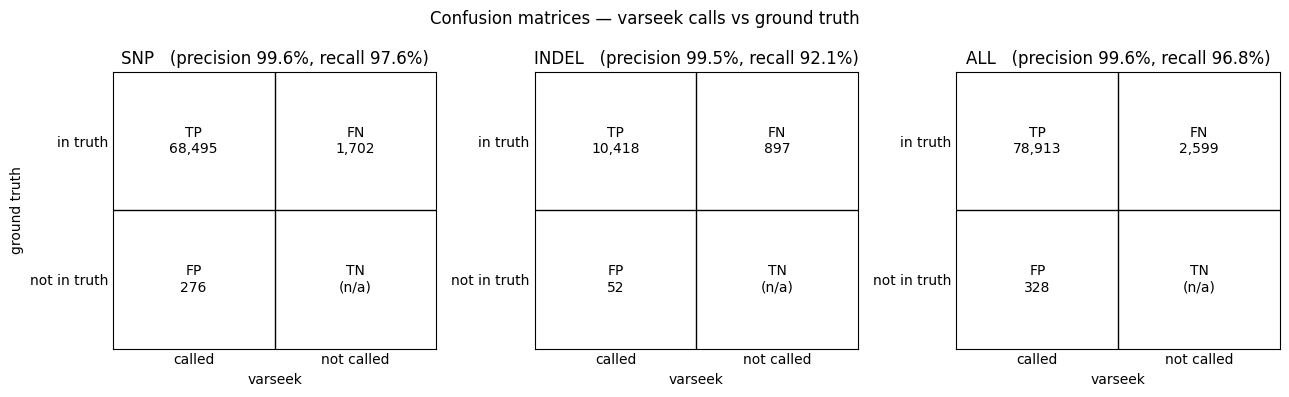

varseek_preliminary — confusion counts (FN shown for reference, excluded from the matrices):
  SNP    TP=69,066   FP=  745   FN= 1,131   precision=98.9%, recall=98.4%
  INDEL  TP=10,729   FP=   91   FN=   586   precision=99.2%, recall=94.8%
  ALL    TP=79,795   FP=  836   FN= 1,717   precision=99.0%, recall=97.9%


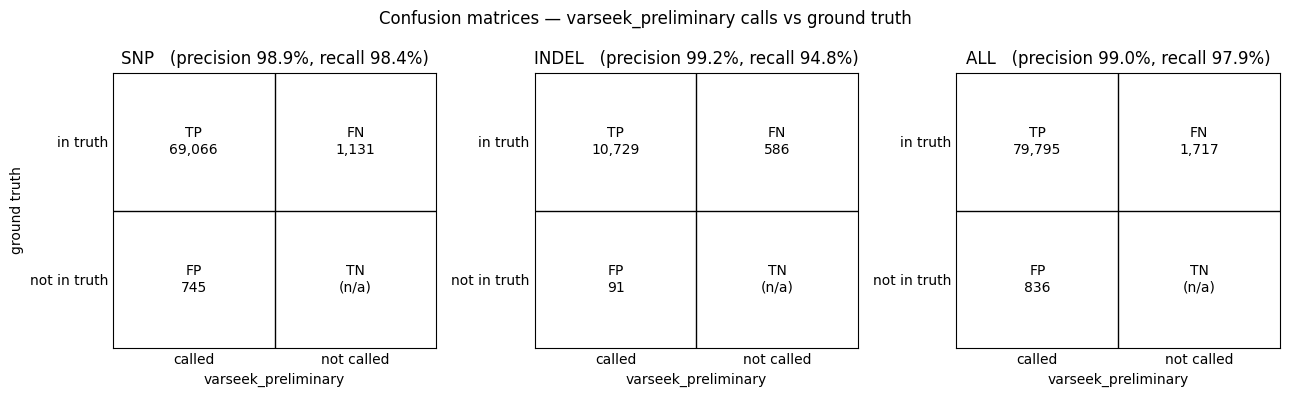

deepvariant — confusion counts (FN shown for reference, excluded from the matrices):
  SNP    TP=68,859   FP=   52   FN= 1,338   precision=99.9%, recall=98.1%
  INDEL  TP=11,135   FP=   43   FN=   180   precision=99.6%, recall=98.4%
  ALL    TP=79,994   FP=   95   FN= 1,518   precision=99.9%, recall=98.1%


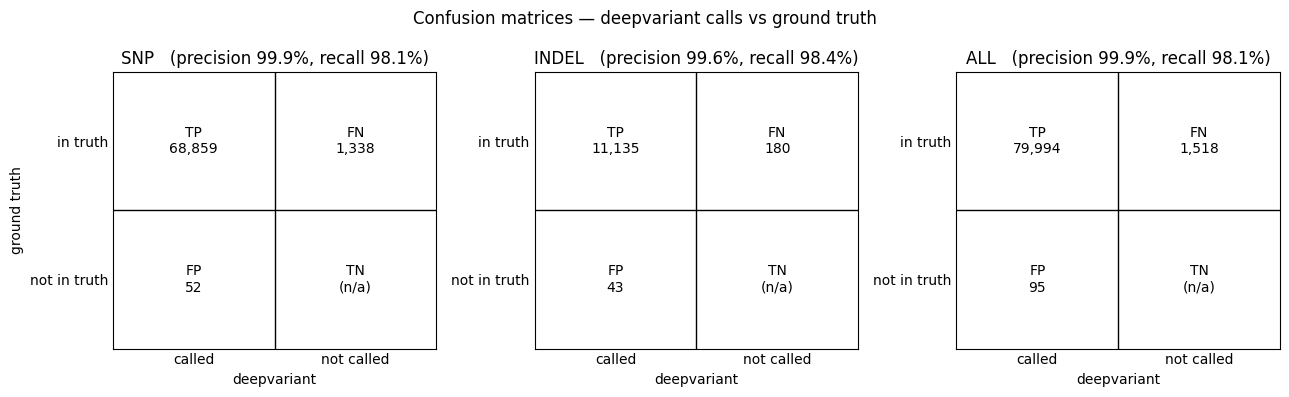

haplotypecaller — confusion counts (FN shown for reference, excluded from the matrices):
  SNP    TP=69,167   FP=   84   FN= 1,030   precision=99.9%, recall=98.5%
  INDEL  TP=11,171   FP=   15   FN=   144   precision=99.9%, recall=98.7%
  ALL    TP=80,338   FP=   99   FN= 1,174   precision=99.9%, recall=98.6%


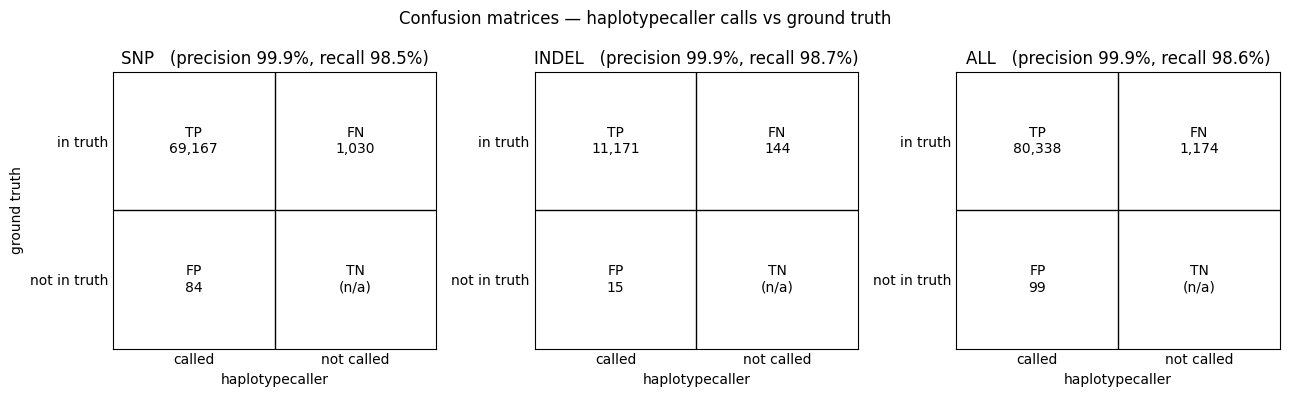

mutect2 — confusion counts (FN shown for reference, excluded from the matrices):
  SNP    TP=58,908   FP=  438   FN=11,289   precision=99.3%, recall=83.9%
  INDEL  TP= 7,888   FP=    7   FN= 3,427   precision=99.9%, recall=69.7%
  ALL    TP=66,796   FP=  445   FN=14,716   precision=99.3%, recall=81.9%


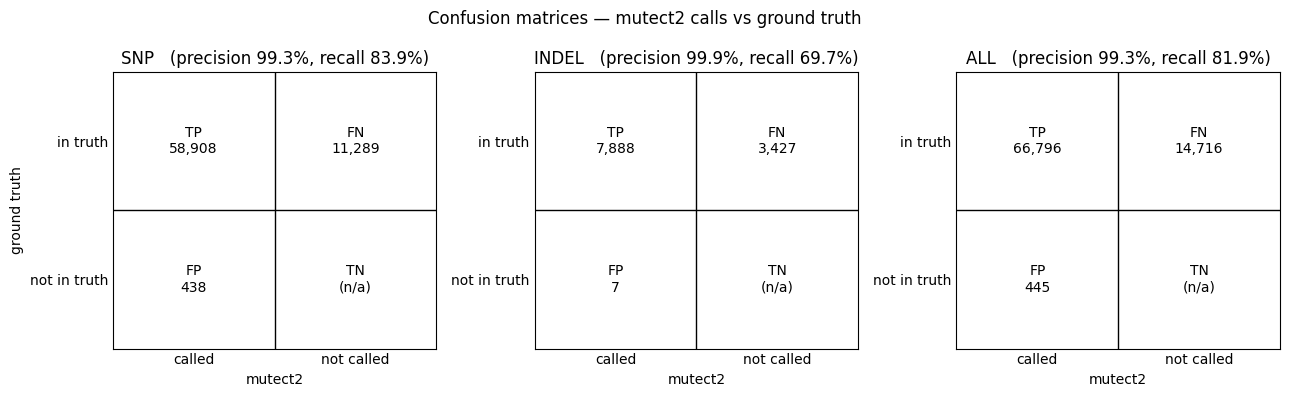

time: 851 ms (started: 2026-08-07 18:21:23 -07:00)


In [32]:
# --- one three-panel confusion matrix figure per caller ---------------------
all_cms = {}
for tool, summary_csv in happy_summaries.items():
    if not os.path.isfile(summary_csv):
        print(f"WARNING: no hap.py summary for {tool}; skipping.")
        continue
    all_cms[tool] = plot_confusion_matrices(summary_csv, tool=tool)

precision_%               recall_%                  F1  \
type                        ALL  INDEL    SNP      ALL  INDEL    SNP   ALL   
tool                                                                         
deepvariant               99.88  99.62  99.92    98.14  98.41  98.09  0.99   
haplotypecaller           99.88  99.87  99.88    98.56  98.73  98.53  0.99   
mutect2                   99.34  99.91  99.26    81.95  69.71  83.92  0.90   
varseek                   99.59  99.50  99.60    96.81  92.07  97.58  0.98   
varseek_preliminary       98.96  99.16  98.93    97.89  94.82  98.39  0.98   

                                 
type                INDEL   SNP  
tool                             
deepvariant          0.99  0.99  
haplotypecaller      0.99  0.99  
mutect2              0.82  0.91  
varseek              0.96  0.99  
varseek_preliminary  0.97  0.99

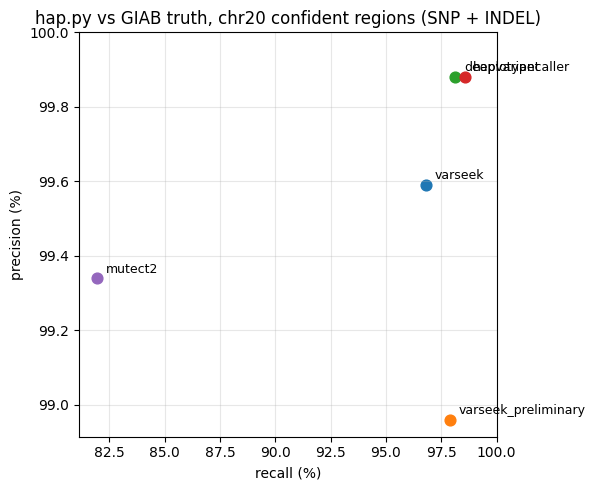

time: 187 ms (started: 2026-08-07 18:21:24 -07:00)


In [33]:
# --- side-by-side precision / recall / F1 across all callers ---------------
rows = []
for tool, cms in all_cms.items():
    for typ, (tp, fp, fn) in cms.items():
        prec, rec = tp / (tp + fp), tp / (tp + fn)
        rows.append({"tool": tool, "type": typ, "TP": tp, "FP": fp, "FN": fn,
                     "precision_%": round(100 * prec, 2), "recall_%": round(100 * rec, 2),
                     "F1": round(2 * prec * rec / (prec + rec), 4) if prec + rec else 0.0})
happy_all_tools = pd.DataFrame(rows)
display(happy_all_tools.pivot(index="tool", columns="type",
                              values=["precision_%", "recall_%", "F1"]).round(2))
happy_all_tools.to_csv(os.path.join(happy_out, "happy_all_tools_summary.csv"), index=False)

# precision-vs-recall scatter (ALL variant types), one point per caller
fig, ax = plt.subplots(figsize=(6, 5))
for tool in all_cms:
    r = happy_all_tools[(happy_all_tools.tool == tool) & (happy_all_tools.type == "ALL")].iloc[0]
    ax.scatter(r["recall_%"], r["precision_%"], s=60)
    ax.annotate(tool, (r["recall_%"], r["precision_%"]), textcoords="offset points",
                xytext=(6, 4), fontsize=9)
ax.set_xlabel("recall (%)"); ax.set_ylabel("precision (%)")
ax.set_title("hap.py vs GIAB truth, chr20 confident regions (SNP + INDEL)")
ax.set_xlim(left=ax.get_xlim()[0], right=100); ax.set_ylim(bottom=ax.get_ylim()[0], top=100)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Two optional precision filters: `remove_alignment_to_reference` (vk ref) × `pseudobam_validation` (vk count)

varseek exposes two independent filters that each trade recall for precision:

- **`remove_alignment_to_reference`** (in `vk ref`) — drops VCRSs whose variant k-mers also align to a normal reference (a d-list). Here we scope it to the **calling assembly, chr20** (`alignment_to_reference_dna=chr20.fa`), since the reads are chr20-only — the biologically correct scope (an off-chr20 paralog can't produce a read).
- **`pseudobam_validation`** (in `vk count`) — re-aligns every read with `kallisto quant --pseudobam` against the whole GRCh38 reference genome (not just chr20, so a read whose true origin is off-chr20 is placed there rather than forced onto chr20) and drops reads whose true genomic coordinate is inconsistent with the variant locus of the VCRS they were assigned to.

`run_varseek_workflow(remove_alignment_to_reference, pseudobam_validation)` below runs the **entire** `vk ref → vk count → adata→VCF → hap.py` pipeline for one setting. We run all four on/off combinations, **skipping any whose outputs already exist** — `(False, False)` is the main run from the top of the notebook (`happy_output/`). Then we compare recall vs precision across the four.

In [34]:
# =========================================================================
# Whole vk ref -> vk count -> hap.py workflow as one function, parameterized by
# the two precision filters. Every heavy step is guarded by output existence,
# so re-running is cheap and already-computed combinations are skipped.
# =========================================================================
project_root = os.getcwd()  # notebook root, where data/ and scripts/ live
# A separate variable, unlike the NA12878 notebook: rebinding the global `root` here means
# any cell rerun afterwards writes into varseek_parameter_tests/ instead of the run dir.
param_test_root = os.path.join(root, "varseek_parameter_tests")

def _run_happy(query_norm, happy_dir):
    summary = os.path.join(happy_dir, "varseek_vs_giab_truth.summary.csv")
    if os.path.isfile(summary):
        return summary
    os.makedirs(happy_dir, exist_ok=True)
    mounts = f"-v {project_root}:{project_root}"
    prefix = os.path.join(os.path.abspath(happy_dir), "varseek_vs_giab_truth")
    subprocess.run(
        f"podman run --rm {mounts} mgibio/hap.py:v0.3.12 /opt/hap.py/bin/hap.py "
        f"-r {os.path.abspath(sequences)} -f {os.path.abspath(confident_bed)} "
        f"--location 20 --threads {threads} --engine=scmp-somatic -o {prefix} "
        f"{os.path.abspath(truth_vcf)} {os.path.abspath(query_norm)}", shell=True, check=True)
    return summary

def run_varseek_workflow(remove_alignment_to_reference, pseudobam_validation):
    """vk ref -> vk count -> adata_to_vcf -> normalize -> hap.py; returns the hap.py summary path."""
    tag = f"rem{int(remove_alignment_to_reference)}_pb{int(pseudobam_validation)}"
    # (False, False) is the main run from the top of the notebook -> reuse its hap.py output
    if not remove_alignment_to_reference and not pseudobam_validation:
        return os.path.join(happy_out, "varseek_vs_giab_truth.summary.csv")

    ref_dir   = os.path.join(param_test_root, f"varseek_ref_out_{tag}")
    count_dir = os.path.join(param_test_root, f"varseek_count_out_{tag}")
    happy_dir = os.path.join(param_test_root, f"happy_output_{tag}")
    idx = os.path.join(ref_dir, "vcrs.idx"); t2g = os.path.join(ref_dir, "vcrs_t2g.txt")
    summary = os.path.join(happy_dir, "varseek_vs_giab_truth.summary.csv")
    if os.path.isfile(summary):
        print(f"[{tag}] outputs exist - skipping"); return summary
    os.makedirs(ref_dir, exist_ok=True)

    # 1) vk ref  (optionally d-list against the chr20 calling assembly)
    if not os.path.exists(idx):
        ref_kwargs = dict(variants=variants, sequences=sequences, seq_id_column="seq_id", var_column="variant",
                          remove_alignment_to_reference=remove_alignment_to_reference, species="human",
                          out=ref_dir, reference_out_dir=reference_dir,
                          index_out=idx, vcrs_t2g_out=t2g, w=w, k=k)
        vk.ref(**ref_kwargs)

    # 2) vk count  (optionally pseudobam-validate reads against the chr20 reference genome)
    if not os.path.exists(count_dir) or not os.path.exists(os.path.join(count_dir, "varseek_variants.vcf")):
        count_kwargs = dict(index=idx, t2g=t2g, technology="dna", parity="paired", out=count_dir,
                            k=k, threads=threads, strand="unstranded", min_counts=min_counts_clean)
        if pseudobam_validation:
            # Shared, prebuilt kallisto index of the whole GRCh38 primary assembly. Anchored in
            # reference_dir (not the per-sample dir) because it is sample-independent, and passed
            # explicitly because letting vk count auto-build it from `sequences` produced a
            # degraded index on this run -- 5.0 GB instead of 8.3 GB, with 0 of 9.48M reads
            # pseudoaligning, after reporting "Finished creating custom index" without error.
            count_kwargs.update(pseudobam_validation=True, sequences=sequences,
                                reference_genome_index=os.path.join(
                                    reference_dir, "genome_kallisto_grch38_wholegenome.idx"),
                                reference_sequences_type="dna")
        res = vk.count([r1, r2], **count_kwargs)

    # 3) adata -> sites VCF -> normalize -> hap.py
    query_vcf = os.path.join(count_dir, "varseek_variants.vcf")
    if not os.path.exists(query_vcf):
        adata_to_vcf(res["adata_path"], query_vcf)
    query_norm = normalize_query(query_vcf, sequences)
    return _run_happy(query_norm, happy_dir)

# --- run all four combinations (skips any already computed) ---
combos = [(False, False), (True, False), (False, True), (True, True)]
combo_summaries = {}
for rem, pb in combos:
    combo_summaries[(rem, pb)] = run_varseek_workflow(rem, pb)
    print(f"remove_alignment_to_reference={rem!s:5s}  pseudobam_validation={pb!s:5s}  ->  {combo_summaries[(rem, pb)]}")

18:21:24 - INFO - parity='paired' and parity_kb_count='single'. This means that kb count will run in single-end mode on this paired-end data, which will enable different pairs to be processed independently and thus potentially detect different variants. To turn this feature off, set parity_kb_count='paired'.


18:21:24 - INFO - Error sorting fastq files: File data/hg003_chr20/reads/HG003_chr20_R1.fastq.gz does not match the expected bulk file naming convention of SAMPLE_PAIR.EXT where SAMPLE is sample name, PAIR is 1/2, and EXT is a fastq extension - or the Illumina file naming convention of SAMPLE_LANE_R[12]_001.fastq.gz, where SAMPLE is letters, numbers, underscores; LANE is numbers with optional leading 0s; pair is either R1 or R2; and it has .fq or .fastq extension (or .fq.gz or .fastq.gz).
Raising exception and exiting because sort_fastqs=True, which requires standard bulk or Illumina file naming convention. Please check fastq file names or set sort_fastqs=False.. Returning unsorted fastq files


18:21:24 - INFO - Setting length_required to 41 if fastqpp is run


18:21:24 - INFO - Skipping vk fastqpp because there was no use for it


18:21:24 - INFO - Running kb count with command: kb count -t 16 -k 41 -i data/hg003_chr20/varseek_parameter_tests/varseek_ref_out_rem0_pb1/vcrs.idx -g data/hg003_chr20/varseek_parameter_tests/varseek_ref_out_rem0_pb1/vcrs_t2g.txt -x BULK --h5ad -o data/hg003_chr20/varseek_parameter_tests/varseek_count_out_rem0_pb1/kb_count_out_vcrs --overwrite --strand unstranded --parity single --union --num --mm data/hg003_chr20/reads/HG003_chr20_R1.fastq.gz data/hg003_chr20/reads/HG003_chr20_R2.fastq.gz


...

[I] Total VCF records:         85204
[I] Non-reference VCF records: 85203


[W] overlapping records at 20:854857 for sample 0
[W] Variants that overlap on the reference allele: 48
[I] Total VCF records:         41519
[I] Non-reference VCF records: 41519


Hap.py v0.3.12


Benchmarking Summary:
Type Filter  TRUTH.TOTAL  TRUTH.TP  TRUTH.FN  QUERY.TOTAL  QUERY.FP  QUERY.UNK  FP.gt  FP.al  METRIC.Recall  METRIC.Precision  METRIC.Frac_NA  METRIC.F1_Score  TRUTH.TOTAL.TiTv_ratio  QUERY.TOTAL.TiTv_ratio  TRUTH.TOTAL.het_hom_ratio  QUERY.TOTAL.het_hom_ratio
INDEL    ALL        11315      4314      7001         6340        14       2015      0      0       0.381264          0.996763        0.317823         0.551556                     NaN                     NaN                        NaN                        NaN
INDEL   PASS        11315      4314      7001         6340        14       2015      0      0       0.381264          0.996763        0.317823         0.551556                     NaN                     NaN                        NaN                        NaN
  SNP    ALL        70197     31229     38968        35179       142       3805      0      0       0.444877          0.995474        0.108161         0.614938                2.295634          

remove_alignment_to_reference=True   pseudobam_validation=True   ->  data/hg003_chr20/varseek_parameter_tests/happy_output_rem1_pb1/varseek_vs_giab_truth.summary.csv
time: 1h 32min 12s (started: 2026-08-07 18:21:24 -07:00)


,remove_alignment,pseudobam,combo,type,TP,FP,recall_%,precision_%,F1
0,False,False,base\n(no filters),SNP,68495,276,97.58,99.60,0.9858
1,False,False,base\n(no filters),INDEL,10418,52,92.07,99.50,0.9564
2,True,False,d-list\nonly,SNP,31217,141,44.47,99.55,0.6148
3,True,False,d-list\nonly,INDEL,4314,14,38.13,99.68,0.5516
4,False,True,pseudobam\nonly,SNP,68326,321,97.33,99.53,0.9842
5,False,True,pseudobam\nonly,INDEL,10387,53,91.80,99.49,0.9549
6,True,True,both filters,SNP,31229,142,44.49,99.55,0.6149
7,True,True,both filters,INDEL,4314,14,38.13,99.68,0.5516


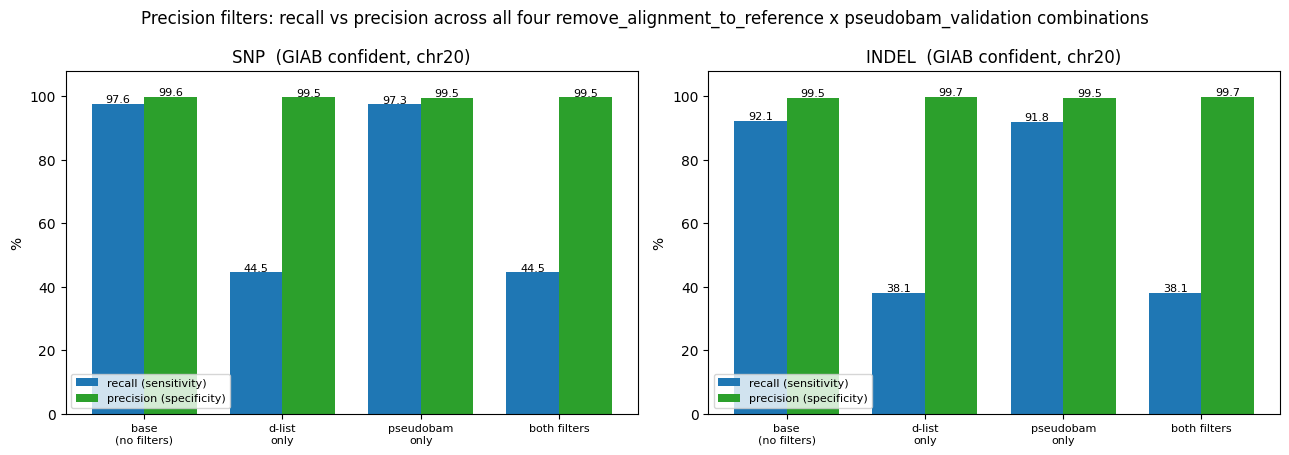

Saved data/hg003_chr20/happy_output/precision_filter_combinations.png
time: 441 ms (started: 2026-08-07 19:53:36 -07:00)


In [35]:
# --- compare recall vs precision across the four filter combinations ---
import matplotlib.pyplot as plt

COMBO_LABELS = {(False, False): "base\n(no filters)", (True, False): "d-list\nonly",
                (False, True): "pseudobam\nonly", (True, True): "both filters"}
order = [(False, False), (True, False), (False, True), (True, True)]

rows = []
for combo in order:
    s = pd.read_csv(combo_summaries[combo])
    s = s[s["Filter"] == "PASS"].set_index("Type")
    for typ in ["SNP", "INDEL"]:
        r = s.loc[typ]
        rows.append({"remove_alignment": combo[0], "pseudobam": combo[1], "combo": COMBO_LABELS[combo],
                     "type": typ, "TP": int(r["TRUTH.TP"]), "FP": int(r["QUERY.FP"]),
                     "recall_%": round(100 * r["METRIC.Recall"], 2),
                     "precision_%": round(100 * r["METRIC.Precision"], 2),
                     "F1": round(r["METRIC.F1_Score"], 4)})
combo_df = pd.DataFrame(rows)
display(combo_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
labels = [COMBO_LABELS[c] for c in order]
for ax, typ in zip(axes, ["SNP", "INDEL"]):
    sub = combo_df[combo_df["type"] == typ].set_index("combo").loc[labels]
    x, wdt = np.arange(len(labels)), 0.38
    ax.bar(x - wdt/2, sub["recall_%"],    wdt, label="recall (sensitivity)",    color="#1f77b4")
    ax.bar(x + wdt/2, sub["precision_%"], wdt, label="precision (specificity)", color="#2ca02c")
    for xi, (rc, pr) in enumerate(zip(sub["recall_%"], sub["precision_%"])):
        ax.text(xi - wdt/2, rc + 0.5, f"{rc:.1f}", ha="center", fontsize=8)
        ax.text(xi + wdt/2, pr + 0.5, f"{pr:.1f}", ha="center", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(f"{typ}  (GIAB confident, chr20)"); ax.set_ylabel("%"); ax.set_ylim(0, 108)
    ax.legend(loc="lower left", fontsize=8)
fig.suptitle("Precision filters: recall vs precision across all four "
             "remove_alignment_to_reference x pseudobam_validation combinations")
fig.tight_layout()
combo_png = os.path.join(happy_out, "precision_filter_combinations.png")
fig.savefig(combo_png, dpi=150, bbox_inches="tight"); plt.show()
print("Saved", combo_png)

### Tool runtimes

Wall-clock runtime for each caller, read back from `tool_runtimes.json`. The three
varseek stages (`vk denovo`, `vk ref`, `vk count`) are recorded separately in the JSON
but summed into a single **varseek** bar (shown stacked so the per-stage breakdown is
still visible). Any tool that was skipped on this run (output already existed) keeps its
previously recorded time.

Recorded runtimes:
  vk denovo           822.8 s  ( 13.71 min)
  vk ref               54.2 s  (  0.90 min)
  vk count             91.8 s  (  1.53 min)
  haplotypecaller    1842.3 s  ( 30.70 min)
  mutect2            1608.3 s  ( 26.80 min)
  deepvariant         983.0 s  ( 16.38 min)
  varseek (total)     968.8 s  ( 16.15 min)


Saved plot -> data/hg003_chr20/tool_runtimes.png


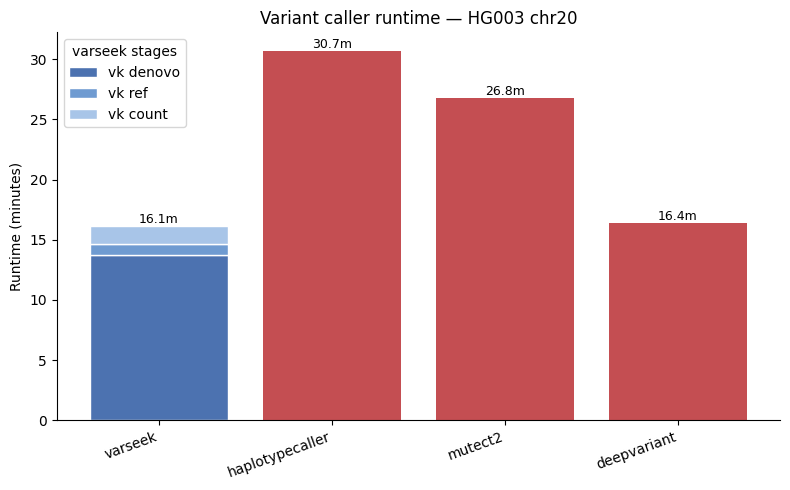

time: 267 ms (started: 2026-08-07 19:53:37 -07:00)


In [36]:
import matplotlib.pyplot as plt

rt = load_runtimes()

varseek_stages = ["vk denovo", "vk ref", "vk count"]
other_tools = ["haplotypecaller", "mutect2", "deepvariant", "vartrix"]

print("Recorded runtimes:")
for name in varseek_stages + other_tools:
    if name in rt:
        print(f"  {name:16s} {rt[name]:8.1f} s  ({rt[name]/60:6.2f} min)")
varseek_total = sum(rt.get(s, 0.0) for s in varseek_stages)
print(f"  {'varseek (total)':16s} {varseek_total:8.1f} s  ({varseek_total/60:6.2f} min)")

# --- build bars: one stacked varseek bar + one bar per other tool present ----
present_others = [(t, rt[t]) for t in other_tools if t in rt]
stage_vals = [rt.get(s, 0.0) for s in varseek_stages]

fig, ax = plt.subplots(figsize=(8, 5))
labels = ["varseek"] + [t for t, _ in present_others]
x = list(range(len(labels)))

# stacked varseek bar (per-stage segments)
stage_colors = ["#4C72B0", "#6f9bd1", "#a8c5e8"]
bottom = 0.0
for val, stage, c in zip(stage_vals, varseek_stages, stage_colors):
    ax.bar(0, val / 60, bottom=bottom / 60, color=c, edgecolor="white", label=stage)
    bottom += val

# other tools
for i, (t, v) in enumerate(present_others, start=1):
    ax.bar(i, v / 60, color="#C44E52")

# annotate totals on top of each bar
totals = [varseek_total] + [v for _, v in present_others]
for xi, tot in zip(x, totals):
    ax.text(xi, tot / 60, f"{tot/60:.1f}m", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("Runtime (minutes)")
ax.set_title("Variant caller runtime — HG003 chr20")
ax.legend(title="varseek stages", loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

runtime_plot_png = os.path.join(root, "tool_runtimes.png")
plt.savefig(runtime_plot_png, dpi=150)
print(f"Saved plot -> {runtime_plot_png}")
plt.show()

## varseek in genotyping mode: screening the HG003 reads against COSMIC

Everything above is *de novo*: `vk denovo` proposes the variants and `vk ref` builds the variant
reference from them. varseek's other mode is **genotyping** — build the VCRS reference once from a
fixed catalog of known variants and screen reads against it, with no variant-calling step at all.
Here the catalog is the **COSMIC Cancer Mutation Census (v104, GRCh38)**, ~2.4 M records genome-wide,
and the same HG003 chr20 reads are screened against it.

**The truth set has to be restricted the same way.** A screen can only ever report variants that are
in its catalog, so scoring it against the full GIAB truth would mostly measure how much of HG003
COSMIC happens to contain. The truth VCF is therefore intersected with the COSMIC catalog
(chr20, GIAB confident regions), and recall is measured over the variants varseek was actually given
a chance to find. Precision needs no such adjustment: every call here is a COSMIC variant by
construction, so a call missing from the restricted truth is missing from the full truth too.

COSMIC is a catalog of somatic cancer mutations and HG003 is a healthy germline sample, so the
intersection is small (~150 chr20 truth variants on HG001; recomputed below for HG003) — the interesting quantity is how cleanly the
screen recovers exactly those, and how few extra COSMIC entries it wrongly reports.

In [37]:
# ---- COSMIC genotyping-mode paths and parameters ----
# The catalog reference is genome-wide (COSMIC is not chr20-specific); the reads are chr20, and
# hap.py scopes the evaluation to chr20 confident regions exactly as it does for the de novo run.
cosmic_tsv = os.path.join("data", "cosmic", "Cosmic_MutantCensus_v104_GRCh38.tsv")

# Unlike the NA12878 notebook, the filter-combination cell above does not rebind `root`
# (it uses `param_test_root`), so `root` is still the run directory here. Kept as an explicit
# name because the COSMIC outputs and the hap.py bind-mount both need the run-dir base.
hg003_root = root

# vk ref out (COSMIC catalog)
vk_ref_out_dir_cosmic = os.path.join(hg003_root, "varseek_ref_out_cosmic")
vcrs_index_cosmic = os.path.join(vk_ref_out_dir_cosmic, "vcrs_index_cosmic.idx")
vcrs_t2g_cosmic = os.path.join(vk_ref_out_dir_cosmic, "vcrs_t2g_cosmic.txt")

# vk count out (COSMIC screen)
vk_count_out_dir_cosmic = os.path.join(hg003_root, "varseek_count_out_cosmic")
vk_count_variants_vcf_cosmic = os.path.join(vk_count_out_dir_cosmic, "varseek_variants.vcf")

# COSMIC catalog as VCF + the COSMIC-restricted GIAB truth built from it
cosmic_sites_vcf = os.path.join(giab_dir, "cosmic_chr20_sites.vcf")
cosmic_norm_vcf = os.path.join(giab_dir, "cosmic_chr20_normalized.vcf.gz")
truth_vcf_cosmic = os.path.join(giab_dir, "truth_chr20_ens_cosmic_only.vcf.gz")

os.makedirs(vk_ref_out_dir_cosmic, exist_ok=True)
os.makedirs(vk_count_out_dir_cosmic, exist_ok=True)
print("COSMIC catalog:", cosmic_tsv)

COSMIC catalog: data/cosmic/Cosmic_MutantCensus_v104_GRCh38.tsv
time: 1.23 ms (started: 2026-08-07 19:53:37 -07:00)


In [38]:
# vk ref reads the catalog as a table of (seq_id, variant) HGVS parts; COSMIC ships the two
# glued together in HGVSG ("20:g.31022441C>T"), so split them once and cache the result in the TSV.
if not os.path.exists(cosmic_tsv):
    raise FileNotFoundError(f"Cosmic TSV not found at {cosmic_tsv}; please download from https://cancer.sanger.ac.uk/cosmic/download/cosmic/v104/mutantcensus.")

cosmic_tsv_cols = pd.read_csv(cosmic_tsv, sep="\t", nrows=0).columns
if "seq_id" not in cosmic_tsv_cols or "variant" not in cosmic_tsv_cols:
    cosmic_df = pd.read_csv(cosmic_tsv, sep="\t", low_memory=False)
    cosmic_df[["seq_id", "variant"]] = cosmic_df["HGVSG"].str.split(":", n=1, expand=True)
    cosmic_df.to_csv(cosmic_tsv, sep="\t", index=False)
    print(f"Added seq_id/variant columns to {cosmic_tsv} ({len(cosmic_df):,} records)")
else:
    print("COSMIC TSV already carries seq_id/variant columns")

COSMIC TSV already carries seq_id/variant columns


time: 6.74 ms (started: 2026-08-07 19:53:37 -07:00)


In [39]:
# Build the VCRS reference from the whole COSMIC census. Two settings are deliberately the
# same as the de novo build above so the two modes stay comparable:
#   * w = k - 1. A shorter flank means any second variant within (k-1-w) bp of the first leaves
#     no clean variant k-mer, and that VCRS can never be hit.
#   * remove_alignment_to_reference=False -- no d-list. `species="human"` is NOT passed: it makes
#     vk ref d-list against T2T while we call against GRCh38, which strips genuine variants
#     (see the d-list discussion above).
if not os.path.exists(vcrs_index_cosmic):
    with record_runtime("vk ref (COSMIC)"):
        vk_ref_output_dict_cosmic = vk.ref(
            variants=cosmic_tsv,
            sequences=sequences,
            seq_id_column="seq_id",
            var_column="variant",
            remove_alignment_to_reference=False,
            out=vk_ref_out_dir_cosmic,
            reference_out_dir=reference_dir,
            vcrs_unfiltered_fasta_out=os.path.join(vk_ref_out_dir_cosmic, "vcrs_unfiltered.fa"),
            save_variants_updated_dataframe=False,
            index_out=vcrs_index_cosmic,
            vcrs_t2g_out=vcrs_t2g_cosmic,
            w=w,
            k=k,
            threads=threads,
        )
print("COSMIC VCRS index:", vcrs_index_cosmic)
print("VCRSs in the COSMIC reference:", sum(1 for _ in open(vcrs_t2g_cosmic)))

COSMIC VCRS index: data/hg003_chr20/varseek_ref_out_cosmic/vcrs_index_cosmic.idx


VCRSs in the COSMIC reference: 1451908
time: 109 ms (started: 2026-08-07 19:53:37 -07:00)


In [40]:
# Screen the same paired HG003 chr20 reads against the COSMIC index. Bulk DNA mode
# (technology="dna", parity="paired"), identical to the de novo vk count call above --
# only the reference differs.
adata_path_cosmic = os.path.join(vk_count_out_dir_cosmic, "adata_cleaned.h5ad")
if not os.path.exists(adata_path_cosmic):
    with record_runtime("vk count (COSMIC)"):
        vk_count_output_dict_cosmic = vk.count(
            [r1, r2],
            index=vcrs_index_cosmic,
            t2g=vcrs_t2g_cosmic,
            technology="dna",
            parity="paired",
            out=vk_count_out_dir_cosmic,
            k=k,
            threads=threads,
            strand="unstranded",
            min_counts=min_counts_clean,
        )
    adata_path_cosmic = vk_count_output_dict_cosmic["adata_path"]
print("adata:", adata_path_cosmic)

adata: data/hg003_chr20/varseek_count_out_cosmic/adata_cleaned.h5ad
time: 742 μs (started: 2026-08-07 19:53:37 -07:00)


In [41]:
# Recount from the BUS file, exactly as for the de novo run -- and it matters more here.
# `bustools count --multimapping --cm` gives a VCRS floor(reads_in_EC / targets_in_EC) per
# equivalence class, and a catalog-scale reference puts many more VCRSs in each EC (COSMIC
# stores overlapping records at the same locus), so the integer division truncates far more
# aggressively than it does on the small de novo index. Counting compatible reads instead
# thresholds evidence rather than an artefact of integer division.
kb_count_dir_cosmic = os.path.join(vk_count_out_dir_cosmic, "kb_count_out_vcrs")
adata_vcrs_cosmic = ad.read_h5ad(adata_path_cosmic)
vcrs_counts_cosmic = vcrs_read_counts(kb_count_dir_cosmic, adata_vcrs_cosmic.var_names)

bustools_counts_cosmic = np.asarray(adata_vcrs_cosmic.X.sum(axis=0)).ravel()
n_bustools_c = int((bustools_counts_cosmic > 0).sum())
n_recount_c = int((vcrs_counts_cosmic > 0).sum())
n_thresh_c = int((vcrs_counts_cosmic >= min_supporting_reads).sum())
print(f"VCRSs in the COSMIC index                   : {len(vcrs_counts_cosmic):,}")
print(f"  detected by bustools (floor(reads/|EC|))  : {n_bustools_c:,}")
print(f"  with >=1 compatible read (recount)        : {n_recount_c:,}   (+{n_recount_c - n_bustools_c:,} zeroed by integer division)")
print(f"  with >={min_supporting_reads} compatible reads (called)      : {n_thresh_c:,}")

VCRSs in the COSMIC index                   : 1,451,908
  detected by bustools (floor(reads/|EC|))  : 37,880
  with >=1 compatible read (recount)        : 53,295   (+15,415 zeroed by integer division)
  with >=3 compatible reads (called)      : 46,693
time: 9.59 s (started: 2026-08-07 19:53:37 -07:00)


In [42]:
# Same AnnData -> sites-only VCF -> normalize path as the de novo calls, so both call sets
# reach hap.py in one coordinate representation.
adata_to_vcf(adata_path_cosmic, vk_count_variants_vcf_cosmic,
             counts=vcrs_counts_cosmic, min_reads=min_supporting_reads)
query_norm_cosmic = normalize_query(vk_count_variants_vcf_cosmic, sequences)
print("normalized COSMIC-screen calls:", query_norm_cosmic)

data/hg003_chr20/varseek_count_out_cosmic/varseek_variants.vcf already exists, skipping VCF writing.


Writing to /home/jrich/tmp/bcftools.9Vzp2Z


Lines   total/split/joined/realigned/mismatch_removed/dup_removed/skipped:	45108/0/0/1965/0/0/0
Merging 1 temporary files
Done
Cleaning


normalized COSMIC-screen calls: data/hg003_chr20/varseek_count_out_cosmic/varseek_variants_normalized.vcf.gz
time: 665 ms (started: 2026-08-07 19:53:47 -07:00)


In [43]:
# =========================================================================
# Ground truth for the screen: GIAB truth restricted to variants that are in COSMIC.
#
# A catalog screen cannot report anything outside its catalog, so its recall must be measured
# over GIAB (intersect) COSMIC, not over all of GIAB. Precision is unaffected -- every call is a COSMIC
# variant by construction, so a call absent from the restricted truth is absent from the full
# truth too.
#
# COSMIC's HGVS strings are converted to VCF records with the *same* grammar `adata_to_vcf`
# applies to the varseek calls (SNV / ins / del), so both sides of the comparison share one
# representation. The HGVS types that grammar does not express (dup, delins, inv -- ~2% of
# chr20 COSMIC) drop out of the truth *and* are unparseable on the query side, so the omission
# is symmetric rather than a hidden recall penalty. Matching is left to bcftools: both files are
# left-normalized against the same reference and intersected on POS+REF+ALT (`isec -n=2 -w1`),
# which keeps the GIAB record (with its genotypes) wherever a COSMIC record matches it.
# =========================================================================
def cosmic_hgvs_to_vcf_df(hgvs_strings, fasta):
    """`seq_id:variant` HGVS genomic strings -> CHROM/POS/REF/ALT frame + count of unparsed
    strings. Mirrors the parser in `adata_to_vcf` so truth and query agree on representation."""
    var_series = pd.Series(list(hgvs_strings), dtype="object").str.split(";").explode()
    var_series = var_series[var_series.str.len() > 0].reset_index(drop=True)
    snv = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<POS>\d+)(?P<REF>[ACGT]+)>(?P<ALT>[ACGT]+)$")
    ins = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<POS>\d+)_(?P<END>\d+)ins(?P<INS>[ACGT]+)$")
    dele = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<START>\d+)(?:_(?P<END>\d+))?del(?P<DEL>[ACGT]*)$")
    snv_mask, ins_mask, del_mask = snv["CHROM"].notna(), ins["CHROM"].notna(), dele["START"].notna()
    n_unparsed = int((~(snv_mask | ins_mask | del_mask)).sum())

    frames = []
    snv = snv[snv_mask]
    if not snv.empty:
        frames.append(pd.DataFrame({"CHROM": snv["CHROM"], "POS": snv["POS"].astype(int),
                                    "REF": snv["REF"], "ALT": snv["ALT"]}))
    ins = ins[ins_mask]
    if not ins.empty:
        ins_pos = ins["POS"].astype(int)
        anchor = pd.Series([fasta.fetch(c, p - 1, p) for c, p in zip(ins["CHROM"], ins_pos)], index=ins.index)
        frames.append(pd.DataFrame({"CHROM": ins["CHROM"], "POS": ins_pos,
                                    "REF": anchor, "ALT": anchor + ins["INS"]}))
    dele = dele[del_mask]
    if not dele.empty:
        start = dele["START"].astype(int)
        end = pd.to_numeric(dele["END"]).fillna(start).astype(int)
        anchor = pd.Series([fasta.fetch(c, s - 2, s - 1) for c, s in zip(dele["CHROM"], start)], index=dele.index)
        deleted = pd.Series([d if isinstance(d, str) and d != "" else fasta.fetch(c, s - 1, e)
                             for c, s, e, d in zip(dele["CHROM"], start, end, dele["DEL"])], index=dele.index)
        frames.append(pd.DataFrame({"CHROM": dele["CHROM"], "POS": start - 1,
                                    "REF": anchor + deleted, "ALT": anchor}))
    df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(columns=["CHROM", "POS", "REF", "ALT"])
    return df, n_unparsed


if not os.path.exists(truth_vcf_cosmic):
    # chr20 slice of the catalog (the truth VCF is chr20-only), deduplicated: COSMIC lists one
    # row per (variant, sample), so the same variant appears many times.
    cosmic_chr20 = pd.concat(
        chunk[chunk["seq_id"] == "20"]
        for chunk in pd.read_csv(cosmic_tsv, sep="\t", usecols=["seq_id", "variant"],
                                 dtype=str, chunksize=1_000_000)
    ).dropna()
    cosmic_hgvs = (cosmic_chr20["seq_id"] + ":" + cosmic_chr20["variant"]).drop_duplicates()
    print(f"COSMIC chr20: {len(cosmic_chr20):,} records -> {len(cosmic_hgvs):,} unique variants")

    cosmic_vcf_df, n_unparsed = cosmic_hgvs_to_vcf_df(cosmic_hgvs, pysam.FastaFile(sequences))
    cosmic_vcf_df = cosmic_vcf_df.drop_duplicates().sort_values(["POS", "REF", "ALT"])
    print(f"  convertible to VCF (SNV/ins/del): {len(cosmic_vcf_df):,}"
          f"   not expressible (dup/delins/inv): {n_unparsed:,}")

    with open(cosmic_sites_vcf, "w") as fh:
        fh.write("##fileformat=VCFv4.2\n#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\n")
        fh.write("".join(cosmic_vcf_df["CHROM"].astype(str) + "\t" + cosmic_vcf_df["POS"].astype(str)
                         + "\t.\t" + cosmic_vcf_df["REF"] + "\t" + cosmic_vcf_df["ALT"] + "\t.\t.\t.\n"))

    # left-normalize the catalog exactly as the truth VCF was normalized, then intersect
    fai = f"{sequences}.fai"
    if not os.path.isfile(fai):
        subprocess.run(["samtools", "faidx", sequences], check=True)
    reheader = subprocess.Popen(["bcftools", "reheader", "--fai", fai, cosmic_sites_vcf], stdout=subprocess.PIPE)
    norm = subprocess.Popen(["bcftools", "norm", "-c", "w", "-f", sequences, "-m", "-both", "-Ou"],
                            stdin=reheader.stdout, stdout=subprocess.PIPE); reheader.stdout.close()
    subprocess.run(["bcftools", "sort", "-Oz", "-o", cosmic_norm_vcf], stdin=norm.stdout, check=True)
    norm.stdout.close(); reheader.wait(); norm.wait()
    subprocess.run(["bcftools", "index", "-f", "-t", cosmic_norm_vcf], check=True)

    subprocess.run(["bcftools", "isec", "-n=2", "-w1", "-Oz", "-o", truth_vcf_cosmic,
                    truth_vcf, cosmic_norm_vcf], check=True)
    subprocess.run(["bcftools", "index", "-f", "-t", truth_vcf_cosmic], check=True)


def _n_records(vcf):
    return int(subprocess.run(f"bcftools view -H {vcf} | wc -l", shell=True,
                              capture_output=True, text=True).stdout)

n_truth_all, n_truth_cosmic = _n_records(truth_vcf), _n_records(truth_vcf_cosmic)
print(f"GIAB truth (chr20)              : {n_truth_all:,}")
print(f"GIAB truth also in COSMIC       : {n_truth_cosmic:,}  ({100 * n_truth_cosmic / n_truth_all:.2f}%)")
print("COSMIC-restricted truth VCF     :", truth_vcf_cosmic)

GIAB truth (chr20)              : 85,204
GIAB truth also in COSMIC       : 132  (0.15%)
COSMIC-restricted truth VCF     : data/hg003_chr20/giab/truth_chr20_ens_cosmic_only.vcf.gz
time: 326 ms (started: 2026-08-07 19:53:48 -07:00)


In [44]:
summary_csv_cosmic = os.path.join(happy_out, "varseek_cosmic_vs_giab_truth.summary.csv")
if not os.path.isfile(summary_csv_cosmic):
    # All inputs/outputs live under the HG003 working dir and the reference dir; mount each once.
    mount_dirs = sorted({os.path.abspath(hg003_root), os.path.abspath(reference_dir)})
    mounts = " ".join(f"-v {d}:{d}" for d in mount_dirs)
    prefix = os.path.join(os.path.abspath(happy_out), "varseek_cosmic_vs_giab_truth")
    cmd = (f"podman run --rm {mounts} "
           f"mgibio/hap.py:v0.3.12 /opt/hap.py/bin/hap.py "
           f"-r {os.path.abspath(sequences)} -f {os.path.abspath(confident_bed)} "
           f"--location 20 --threads {threads} --engine=scmp-somatic -o {prefix} "
           f"{os.path.abspath(truth_vcf_cosmic)} {os.path.abspath(query_norm_cosmic)}")
    print(cmd)
    subprocess.run(cmd, shell=True, check=True)
print("hap.py summary:", summary_csv_cosmic)

hap.py summary: data/hg003_chr20/happy_output/varseek_cosmic_vs_giab_truth.summary.csv
time: 995 μs (started: 2026-08-07 19:53:48 -07:00)


,Type,Filter,TRUTH.TOTAL,TRUTH.TP,TRUTH.FN,QUERY.TOTAL,QUERY.FP,METRIC.Recall,METRIC.Precision,METRIC.F1_Score
0,INDEL,PASS,15,14,1,122,68,0.933333,0.180723,0.302812
1,SNP,PASS,109,108,1,997,761,0.990826,0.123272,0.219264



TRUTH = GIAB HG003 v4.2.1 (chr20, high-confidence) restricted to COSMIC v104 variants; QUERY = varseek COSMIC-screen calls
varseek COSMIC screen — confusion counts (FN shown for reference, excluded from the matrices):
  SNP    TP=   108   FP=  761   FN=     1   precision=12.4%, recall=99.1%
  INDEL  TP=    14   FP=   68   FN=     1   precision=17.1%, recall=93.3%
  ALL    TP=   122   FP=  829   FN=     2   precision=12.8%, recall=98.4%


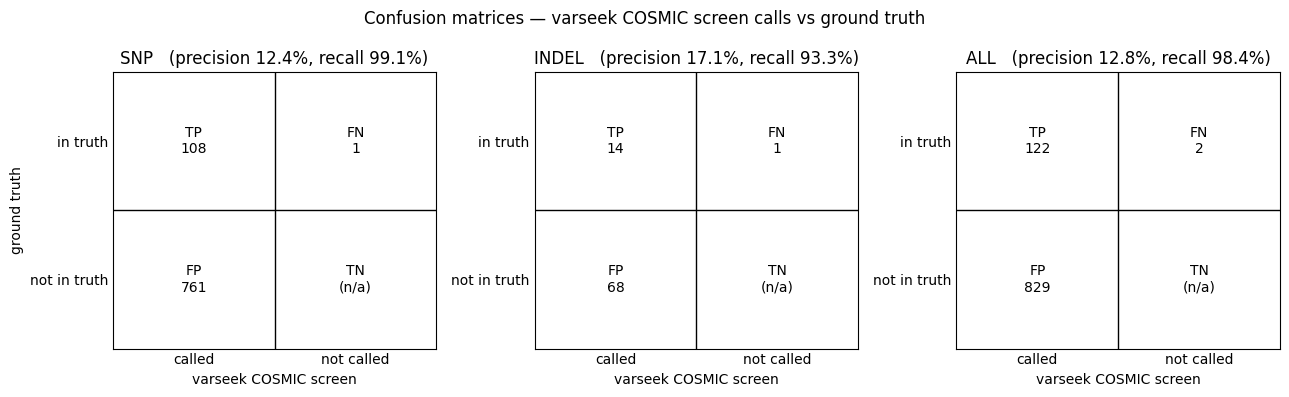

time: 170 ms (started: 2026-08-07 19:53:48 -07:00)


In [45]:
summary_cosmic = pd.read_csv(summary_csv_cosmic)
cols = ["Type", "Filter", "TRUTH.TOTAL", "TRUTH.TP", "TRUTH.FN", "QUERY.TOTAL", "QUERY.FP",
        "METRIC.Recall", "METRIC.Precision", "METRIC.F1_Score"]
display(summary_cosmic[summary_cosmic["Filter"] == "PASS"][cols].reset_index(drop=True))
print("\nTRUTH = GIAB HG003 v4.2.1 (chr20, high-confidence) restricted to COSMIC v104 variants; "
      "QUERY = varseek COSMIC-screen calls")

varseek_cosmic_cms = plot_confusion_matrices(summary_csv_cosmic, tool="varseek COSMIC screen")

In [46]:
# =========================================================================
# Why is the screen's precision so low? Are the false positives thin evidence -- which a
# higher read threshold would clear -- or something depth cannot separate?
#
# hap.py annotates every record of its output VCF with FORMAT/BD (TP / FP / UNK) on the QUERY
# sample, so each call can be joined back to the read support its VCRS actually received.
# SNVs only: they are ~90% of the false positives, and their VCF representation is untouched by
# normalization, so the (POS, REF, ALT) join back to the HGVS variant names is exact.
# =========================================================================
happy_annotated_vcf = os.path.join(happy_out, "varseek_cosmic_vs_giab_truth.vcf.gz")

snv_support = {}
for name, count in zip(adata_vcrs_cosmic.var_names, vcrs_counts_cosmic):
    if count < min_supporting_reads:
        continue
    for v in str(name).split(";"):
        hit = re.match(r"^20:g\.(\d+)([ACGT]+)>([ACGT]+)$", v)
        if hit:
            key = (int(hit.group(1)), hit.group(2), hit.group(3))
            snv_support[key] = max(count, snv_support.get(key, 0))

support = {"TP": [], "FP": []}
with gzip.open(happy_annotated_vcf, "rt") as fh:
    for line in fh:
        if line.startswith("#"):
            continue
        f = line.rstrip("\n").split("\t")
        query = dict(zip(f[8].split(":"), f[10].split(":")))   # sample 2 of the hap.py VCF = query
        if query.get("BVT") != "SNP" or query.get("BD") not in ("TP", "FP"):
            continue
        count = snv_support.get((int(f[1]), f[3], f[4]))
        if count:
            support[query["BD"]].append(count)

for label in ("TP", "FP"):
    arr = np.array(support[label])
    print(f"{label} SNVs: n={len(arr):4d}   median reads={np.median(arr):6.0f}   "
          f"<=10 reads: {100 * np.mean(arr <= 10):4.1f}%   max reads={arr.max():,.0f}")

print(f"\nSNP precision if the {min_supporting_reads}-read call threshold were raised:")
for thr in (min_supporting_reads, 5, 10, 20, 30):
    n_tp = int((np.array(support["TP"]) >= thr).sum())
    n_fp = int((np.array(support["FP"]) >= thr).sum())
    print(f"  >= {thr:2d} reads : TP={n_tp:4d}  FP={n_fp:4d}  precision={100 * n_tp / max(n_tp + n_fp, 1):5.1f}%")

TP SNVs: n= 107   median reads=    28   <=10 reads:  2.8%   max reads=8,706
FP SNVs: n= 761   median reads=    86   <=10 reads:  7.2%   max reads=29,407

SNP precision if the 3-read call threshold were raised:
  >=  3 reads : TP= 107  FP= 761  precision= 12.3%
  >=  5 reads : TP= 106  FP= 728  precision= 12.7%
  >= 10 reads : TP= 104  FP= 707  precision= 12.8%
  >= 20 reads : TP=  78  FP= 667  precision= 10.5%
  >= 30 reads : TP=  49  FP= 594  precision=  7.6%
time: 299 ms (started: 2026-08-07 19:53:48 -07:00)


**Takeaway.** *(The percentages below are the HG001 measurements; the cells above recompute them
for HG003.)* Over the variants it was given a chance to find, the screen recovers most of them —
**78% of SNPs and 96% of indels** of the GIAB ∩ COSMIC truth — but at a precision far below the de
novo pipeline's (11–23% here vs 98.6–99.3% above). Recall and precision are not symmetric findings:
the recall number says the k-mer screen works, the precision number says the *catalog* needs
filtering.

The false positives are not thin evidence that a stricter threshold would clear. Their median read
support is several times that of the true positives, and raising the call threshold makes precision
*worse*, not better — the deepest calls are the most wrong. That is the signature of VCRSs pulling in
wild-type reads at full coverage rather than of sampling noise, which is precisely what the
`remove_alignment_to_reference` d-list in `vk ref` exists to remove; it was switched off here to
match the de novo build above. The de novo pipeline never needed it, because its candidate set comes
from the reads and a VCRS only exists where a variant was actually observed. A catalog screen has no
such protection: it carries 1.45 M VCRSs, essentially all of which are absent from this sample. So
the d-list — against the *calling* assembly, as the d-list section above establishes — is the
load-bearing filter in genotyping mode rather than the optional one it is in de novo mode.